In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8-whitegrid")
sns.set(font_scale=1.1)
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [3]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [4]:
OUTPUT_DIR = Path("../worldbank_tableau_project/outputs/event_overlay")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('../worldbank_tableau_project/outputs/event_overlay')

In [8]:
f_df = pd.read_csv("data/feature_engineered_data.csv")

ind_clusters = pd.read_csv("data/indicator_clusters.csv")

country_clusters = pd.read_csv("data/2_df_traj_clusters.csv")


In [9]:
country_clusters.head()

,country_name,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,cat_Demographics_cagr,...,cat_Demographics_coef_variation,cat_Economy_coef_variation,cat_Education_coef_variation,cat_Governance_coef_variation,cat_Health_coef_variation,cat_Labor_coef_variation,cat_LegalAutonomy_coef_variation,cat_WBL_coef_variation,traj_cluster,Cluster_Name
0,Algeria,0.549136,-0.473852,-0.350839,-0.242434,0.224166,-0.921896,0.071014,-0.046670,1.132363,...,-0.984961,-0.771285,-0.461836,-0.725564,-0.991195,-0.349694,-0.598305,-0.939696,1,Education-Led Social Improvers
1,Bahrain,-0.882325,0.760456,-0.350839,-0.242429,0.562547,0.385428,1.146376,1.179822,0.406997,...,0.315590,2.604167,-0.442636,0.572713,-0.173154,-0.351334,1.184993,0.728257,5,Steady Reformers
2,"Egypt, Arab Rep.",2.822389,-0.456292,-0.350839,-0.241799,0.044399,-0.718898,-0.703062,-0.089338,0.434902,...,-0.993434,-0.580586,-0.463862,0.152224,-0.576052,-0.661778,-0.729994,0.182982,1,Education-Led Social Improvers
3,"Iran, Islamic Rep.",1.395218,-0.504950,-0.350839,-0.243086,0.503907,-0.839522,-0.809671,-0.769852,0.757223,...,-0.928377,-0.483635,-0.458877,-1.242557,-0.515632,-1.168541,-0.805958,-1.086998,1,Education-Led Social Improvers
4,Iraq,1.071439,-0.258855,2.711630,-0.242974,-0.647004,0.500046,-0.216368,-0.066263,-0.401704,...,0.112563,1.039634,2.798915,-0.260512,-0.534701,-0.220204,-0.376614,0.152553,1,Education-Led Social Improvers


In [10]:
ind_clusters.head()

,indicator_name,spike_count,dip_count,avg_volatility,slope_mean,momentum_mean,coef_variation,cagr_mean,regional_dev_std,global_event_count,country_event_count,category,PC1,PC2,indicator_cluster,cluster_name
0,A woman can apply for a passport in the same w...,7,0,1.728872,0.020314,0.0,94.620196,0.279537,1.490577e-17,360,61,Other,-0.188365,-0.038576,3,Stable Legal Rights
1,"A woman can be ""head of household"" in the same...",0,4,1.728872,0.014300,0.0,73.882191,0.279537,1.439178e-17,360,61,Other,0.069320,0.360053,0,Gradual Structural Demographic
2,A woman can choose where to live in the same w...,7,0,1.728872,0.003164,0.0,62.335208,0.279537,3.083953e-18,360,61,Other,-0.102443,-0.273513,6,Fully Stabilized Rights
3,A woman can get a job in the same way as a man...,4,0,1.728872,0.001932,0.0,25.379566,0.279537,8.223874e-18,360,61,Other,0.143083,-0.562572,6,Fully Stabilized Rights
4,A woman can obtain a judgment of divorce in th...,0,0,1.728872,0.000000,0.0,0.000000,0.279537,0.000000e+00,360,61,Other,0.406857,-0.774105,6,Fully Stabilized Rights


In [12]:
# If indicator_name is the index, move it to a column
#ind_clusters = ind_clusters.reset_index().rename(columns={"index": "indicator_name"})


In [15]:
#country_clusters = country_clusters.reset_index().rename(columns={"index": "country_name"})

In [11]:
df = f_df.merge(
    ind_clusters[["indicator_name", "indicator_cluster", "cluster_name"]],
    on="indicator_name",
    how="left"
)

df = df.merge(
    country_clusters[["country_name", "traj_cluster", "Cluster_Name"]],
    on="country_name",
    how="left"
)


In [12]:
df.head()

,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,...,coef_variation,momentum,regional_deviation,regional_deviation_std,event_global,event_country,indicator_cluster,cluster_name,traj_cluster,Cluster_Name
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,NaN,NaN,-0.4,-0.730297,NaN,NaN,3,Stable Legal Rights,1,Education-Led Social Improvers
1,Algeria,2001,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,NaN,NaN,-0.4,-0.730297,9/11 Attacks,NaN,3,Stable Legal Rights,1,Education-Led Social Improvers
2,Algeria,2002,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,NaN,NaN,-0.4,-0.730297,NaN,NaN,3,Stable Legal Rights,1,Education-Led Social Improvers
3,Algeria,2003,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,NaN,NaN,-0.4,-0.730297,Iraq War Begins,NaN,3,Stable Legal Rights,1,Education-Led Social Improvers
4,Algeria,2004,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,NaN,NaN,-0.4,-0.730297,Morocco Family Code Reform; Free Trade with US...,NaN,3,Stable Legal Rights,1,Education-Led Social Improvers


In [13]:
df.columns


Index(['country_name', 'year', 'value', 'indicator_id', 'indicator_name',
       'unit_type', 'source', 'source_reliable', 'region', 'category',
       'val_num', 'yoy_change', 'yoy_pct_change', 'yoy_pct_exists',
       'rolling_mean_3y', 'rolling_std_3y', 'rolling_mean_5y',
       'rolling_std_5y', 'cagr', 'spike', 'dip', 'outlier', 'trend_slope',
       'coef_variation', 'momentum', 'regional_deviation',
       'regional_deviation_std', 'event_global', 'event_country',
       'indicator_cluster', 'cluster_name', 'traj_cluster', 'Cluster_Name'],
      dtype='object')

In [14]:
df.isna().sum()

country_name                  0
year                          0
value                         0
indicator_id                  0
indicator_name                0
unit_type                     0
source                        0
source_reliable               0
region                        0
category                      0
val_num                       0
yoy_change                  756
yoy_pct_change            11215
yoy_pct_exists                0
rolling_mean_3y               0
rolling_std_3y             6966
rolling_mean_5y               0
rolling_std_5y             6966
cagr                       8295
spike                         0
dip                           0
outlier                       0
trend_slope                   0
coef_variation             3144
momentum                   5643
regional_deviation            0
regional_deviation_std        0
event_global               3024
event_country             15582
indicator_cluster             0
cluster_name                  0
traj_clu

In [15]:
from models.events import EVENT_MAPPING, SHORT_EVENTS, MAJOR_EVENTS, COUNTRY_YEAR_EVENTS

df["event_global"] = df["year"].apply(lambda y: 1 if 
                                      (y in EVENT_MAPPING or 
                                       y in MAJOR_EVENTS or
                                       y in SHORT_EVENTS)
                                      else 0)


In [16]:
df["event_country"] = df.apply(
    lambda row: 1 if (row["country_name"], row["year"]) in COUNTRY_YEAR_EVENTS 
    or ("All", row["year"]) in COUNTRY_YEAR_EVENTS 
    else 0,
    axis=1
)


In [17]:
df["event_global"].fillna(0, inplace=True)
df["event_country"].fillna(0, inplace=True)


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_44846/480815258.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["event_global"].fillna(0, inplace=True)
/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_44846/480815258.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav

In [18]:
df["event_global"].value_counts()



event_global
1    15120
0     3024
Name: count, dtype: int64

In [19]:
df["event_country"].value_counts()


event_country
0    15582
1     2562
Name: count, dtype: int64

In [20]:
df[df.event_country == 1][["country_name","year"]].drop_duplicates()

,country_name,year
5,Algeria,2005
15,Algeria,2015
19,Algeria,2019
20,Algeria,2020
22,Algeria,2022
...,...,...
15142,United Arab Emirates,2022
16148,West Bank and Gaza,2020
16150,West Bank and Gaza,2022
17156,"Yemen, Rep.",2020


In [22]:
df.isna().sum().sort_values(ascending=False).head(20)

yoy_pct_change            11215
cagr                       8295
rolling_std_5y             6966
rolling_std_3y             6966
momentum                   5643
coef_variation             3144
yoy_change                  756
event_country                 0
event_global                  0
regional_deviation_std        0
regional_deviation            0
spike                         0
indicator_cluster             0
trend_slope                   0
outlier                       0
cluster_name                  0
dip                           0
traj_cluster                  0
country_name                  0
rolling_mean_5y               0
dtype: int64

## Build Event Summary Columns

### Global event year column

In [23]:
df["global_event_name"] = df["year"].map(EVENT_MAPPING).fillna("None")
df["major_event_name"] = df["year"].map(MAJOR_EVENTS).fillna("None")
df["short_event"] = df["year"].map(SHORT_EVENTS).fillna("None")


### Country-specific event annotation

In [24]:
df["country_event_name"] = df.apply(
    lambda row: COUNTRY_YEAR_EVENTS.get((row["country_name"], row["year"]), 
                                        COUNTRY_YEAR_EVENTS.get(("All", row["year"]), 
                                                                "None")),
    axis=1
)


In [26]:
df.head(3)

,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,...,event_global,event_country,indicator_cluster,cluster_name,traj_cluster,Cluster_Name,global_event_name,major_event_name,short_event,country_event_name
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,0,0,3,Stable Legal Rights,1,Education-Led Social Improvers,None,None,None,None
1,Algeria,2001,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,1,0,3,Stable Legal Rights,1,Education-Led Social Improvers,None,9/11 Attacks,None,None
2,Algeria,2002,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,...,0,0,3,Stable Legal Rights,1,Education-Led Social Improvers,None,None,None,None


# Spike/Dip–Event Overlay (Core Analysis)

### Spikes by Year with Event Markers

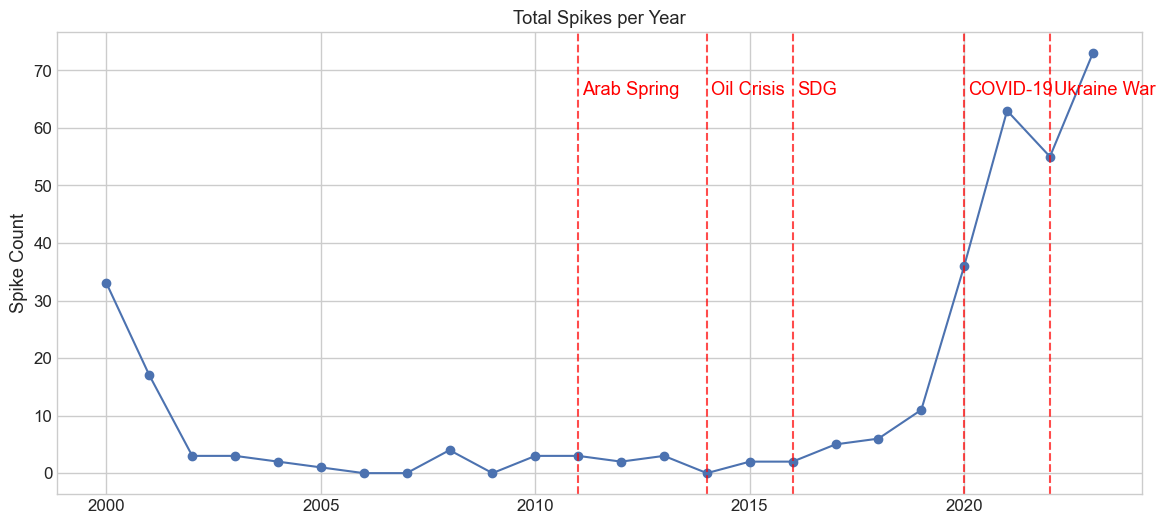

In [28]:
spikes_by_year = df.groupby('year')['spike'].sum()

plt.figure(figsize=(14,6))
plt.plot(spikes_by_year.index, spikes_by_year.values, marker = 'o')
plt.title("Total Spikes per Year")
plt.ylabel("Spike Count")
plt.grid(True)


for year, event in SHORT_EVENTS.items():
    if year in spikes_by_year.index:
        plt.axvline(year, color = 'red', linestyle = "--", alpha = 0.7)
        plt.text(year+0.1,spikes_by_year.max()*0.9, event, color='red')

plt.savefig(OUTPUT_DIR/ "spikes_by_year.png", dpi=300)
plt.show()

### Dips by Year with Event Markers

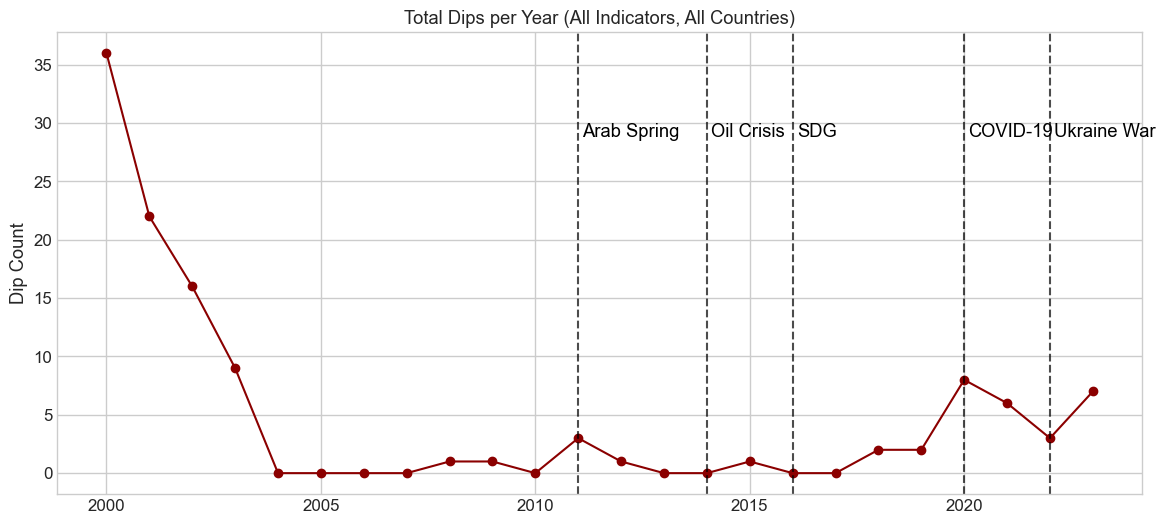

In [30]:
dips_by_year = df.groupby('year')['dip'].sum()

plt.figure(figsize=(14,6))
plt.plot(dips_by_year.index, dips_by_year.values, marker = 'o', color ="darkred")
plt.title("Total Dips per Year (All Indicators, All Countries)")
plt.ylabel("Dip Count")
plt.grid(True)

for year, event in SHORT_EVENTS.items():
    if year in dips_by_year.index:
        plt.axvline(year, color="black", linestyle="--", alpha=0.7)
        plt.text(year+0.1, dips_by_year.max()*0.8, event, color="black")

plt.savefig(OUTPUT_DIR/ "dips_by_year.png", dpi=300)
plt.show()

## Category-Level Shock Sensitivity

### Category Spike Rates During Event Years

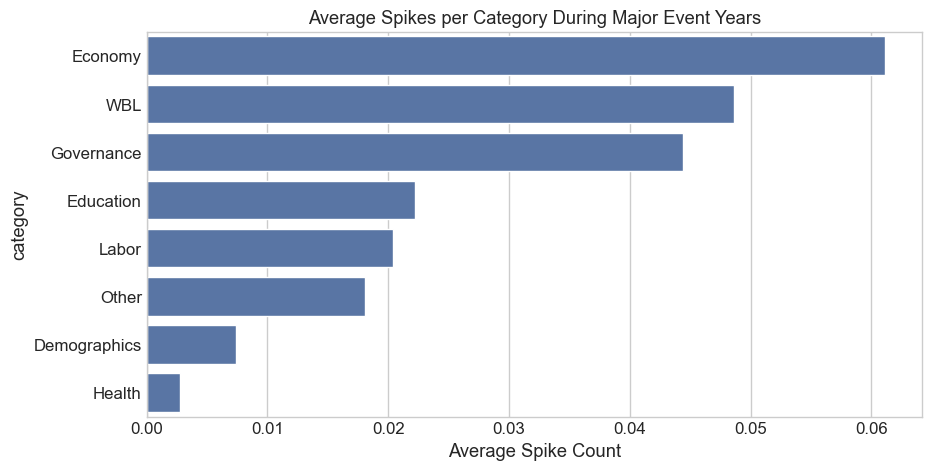

In [31]:
event_years = list(SHORT_EVENTS.keys())

cat_event_spikes = (
    df[df["year"].isin(event_years)]
    .groupby("category")["spike"].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(x=cat_event_spikes.values, y=cat_event_spikes.index)
plt.title("Average Spikes per Category During Major Event Years")
plt.xlabel("Average Spike Count")

plt.savefig(OUTPUT_DIR / "category_spikes.png")
plt.show()


In [46]:
spikes_by_cat_year = df.groupby(["category", "year"])["spike"].sum().unstack(fill_value=0)


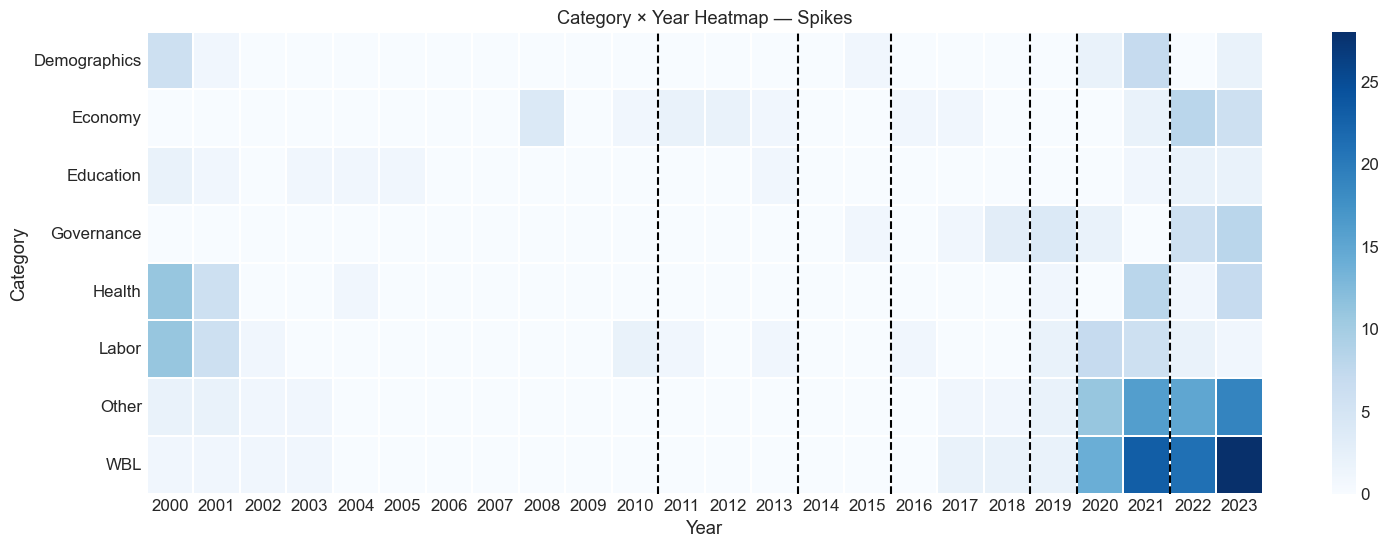

In [51]:
plt.figure(figsize=(18, 6))
sns.heatmap(spikes_by_cat_year, cmap="Blues", linewidths=0.3)
plt.title("Category × Year Heatmap — Spikes")
plt.xlabel("Year")
plt.ylabel("Category")
event_years = [2011, 2014, 2016, 2019, 2020, 2022]

for yr in event_years:
    plt.axvline(x=list(spikes_by_cat_year.columns).index(yr), color='black', linestyle='--')


plt.savefig(OUTPUT_DIR / "category_spikes_heatmap.png")
plt.show()


### Category Dip Rates During Event Years

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_44846/734775777.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_event_dips.values, y=cat_event_dips.index, palette="flare")


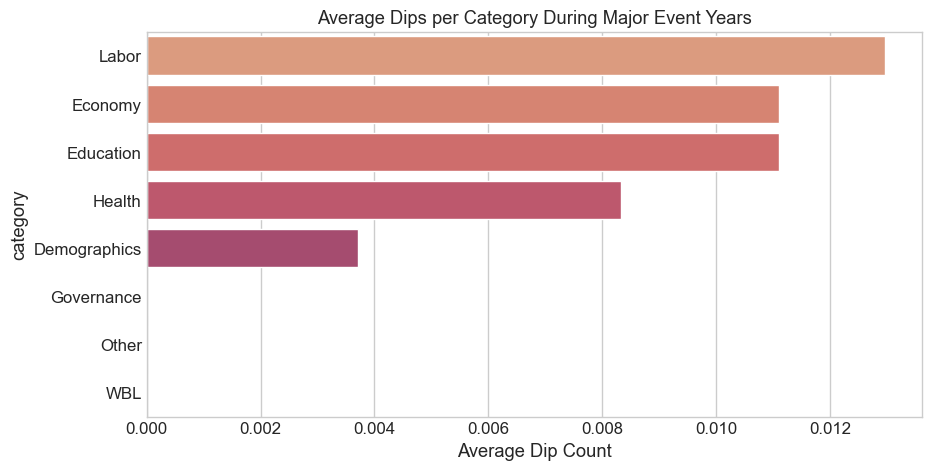

In [32]:
cat_event_dips = (
    df[df["year"].isin(event_years)]
    .groupby("category")["dip"].mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(x=cat_event_dips.values, y=cat_event_dips.index, palette="flare")
plt.title("Average Dips per Category During Major Event Years")
plt.xlabel("Average Dip Count")
plt.savefig(OUTPUT_DIR / "category_dips.png")
plt.show()


In [59]:
dips_by_cat_year = df.groupby(["category", "year"])["dip"].sum().unstack(fill_value=0)


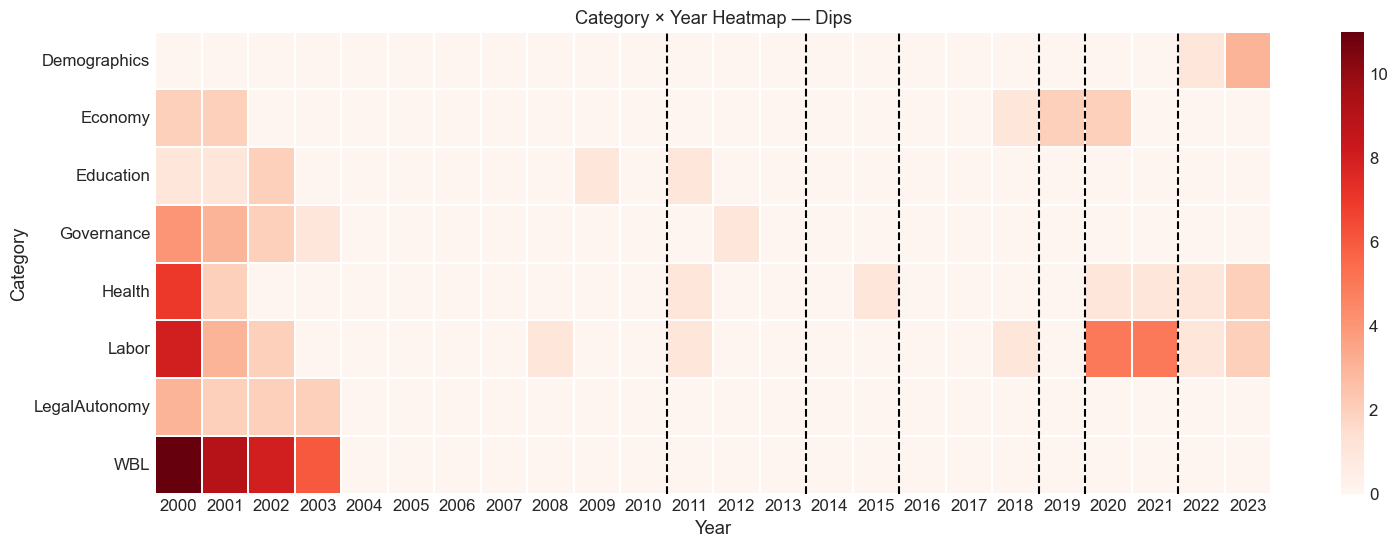

In [60]:
plt.figure(figsize=(18, 6))
sns.heatmap(dips_by_cat_year, cmap="Reds", linewidths=0.3)
plt.title("Category × Year Heatmap — Dips")
plt.xlabel("Year")
plt.ylabel("Category")

for yr in event_years:
    plt.axvline(x=list(dips_by_cat_year.columns).index(yr), color='black', linestyle='--')
    
plt.savefig(OUTPUT_DIR / "category_dips_heatmap.png")
plt.show()

## Category × year heatmap per country

In [61]:
# Ensure types are right
df["year"] = df["year"].astype(int)
df["category"] = df["category"].astype(str)
df["country_name"] = df["country_name"].astype(str)

# Just to confirm
df[["country_name", "year", "category", "spike", "dip"]].head()


,country_name,year,category,spike,dip
0,Algeria,2000,LegalAutonomy,0,0
1,Algeria,2001,LegalAutonomy,0,0
2,Algeria,2002,LegalAutonomy,0,0
3,Algeria,2003,LegalAutonomy,0,0
4,Algeria,2004,LegalAutonomy,0,0


In [54]:
df['category'].value_counts()

category
Other           6912
WBL             3456
Labor           2592
Health          1728
Demographics    1296
Economy          864
Governance       864
Education        432
Name: count, dtype: int64

In [55]:
other_inds = df.loc[df['category'] == 'Other', 'indicator_name'].unique()
len(other_inds), other_inds[:50]

(16,
 array(['A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
        'A woman can be "head of household" in the same way as a man (1=yes; 0=no)',
        'A woman can choose where to live in the same way as a man (1=yes; 0=no)',
        'A woman can get a job in the same way as a man (1=yes; 0=no)',
        'A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)',
        'A woman can open a bank account in the same way as a man (1=yes; 0=no)',
        'A woman can register a business in the same way as a man (1=yes; 0=no)',
        'A woman can sign a contract in the same way as a man (1=yes; 0=no)',
        'A woman can travel outside her home in the same way as a man (1=yes; 0=no)',
        'A woman can travel outside the country in the same way as a man (1=yes; 0=no)',
        'A woman can work at night in the same way as a man (1=yes; 0=no)',
        'A woman can work in a job deemed dangerous in the same way as a man (1=yes; 0=n

In [56]:
# --- Add Legal Autonomy category ---
legal_autonomy_inds = [
    'A woman can apply for a passport in the same way as a man (1=yes; 0=no)',
    'A woman can be "head of household" in the same way as a man (1=yes; 0=no)',
    'A woman can choose where to live in the same way as a man (1=yes; 0=no)',
    'A woman can get a job in the same way as a man (1=yes; 0=no)',
    'A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)',
    'A woman can open a bank account in the same way as a man (1=yes; 0=no)',
    'A woman can register a business in the same way as a man (1=yes; 0=no)',
    'A woman can sign a contract in the same way as a man (1=yes; 0=no)',
    'A woman can travel outside her home in the same way as a man (1=yes; 0=no)',
    'A woman can travel outside the country in the same way as a man (1=yes; 0=no)',
    'A woman can work at night in the same way as a man (1=yes; 0=no)',
    'A woman can work in a job deemed dangerous in the same way as a man (1=yes; 0=no)',
    'A woman can work in an industrial job in the same way as a man (1=yes; 0=no)',
    'A woman has the same rights to remarry as a man (1=yes; 0=no)'
]

df.loc[df["indicator_name"].isin(legal_autonomy_inds), "category"] = "LegalAutonomy"

df.loc[
    df["indicator_name"] == "Women, Business and the Law: Pension Indicator Score (scale 1-100)",
    "category"
] = "WBL"

df.loc[
    df["indicator_name"] == 
    "Criminal penalties or civil remedies exist for sexual harassment in employment (1=yes; 0=no)",
    "category"
] = "Governance"

In [69]:
def plot_country_cat_year_heatmap(df, country, value_col="spike", 
                                  title_prefix="Spikes", 
                                  cmap="Blues",save_path=None):
    """
    df         : long panel with columns [country_name, year, category, spike, dip, ...]
    country    : country_name string
    value_col  : 'spike' or 'dip'
    title_prefix: text to show before country name in the title
    cmap       : seaborn/matplotlib colormap name
    """
    
    # 1) Filter for this country
    sub = df[df["country_name"] == country].copy()
    if sub.empty:
        print(f"No data for {country}")
        return
    
    # 2) Aggregate by category × year
    agg = (
        sub.groupby(["category", "year"])[value_col]
           .sum()
           .reset_index()
    )
    
    # 3) Pivot to category × year matrix
    mat = (
        agg.pivot(index="category", columns="year", values=value_col)
           .fillna(0)
           .sort_index()         # sort categories alphabetically
    )
    
    years = mat.columns.values
    
    # 4) Build figure
    plt.figure(figsize=(14, 5))
    ax = sns.heatmap(
        mat,
        cmap=cmap,
        linewidths=0.3,
        linecolor="lightgrey",
        cbar_kws={"label": f"{value_col.capitalize()} Count"},
    )
    
    ax.set_xlabel("Year")
    ax.set_ylabel("Category")
    ax.set_title(f"{title_prefix} – {country}", fontsize=14, pad=15)
    
    # 5) Overlay **global / major events** (vertical lines)
    # Only draw lines for years that are within the heatmap range
    ymin, ymax = ax.get_ylim()
    
    # Global / major events
    for year, label in MAJOR_EVENTS.items():
        if year in years:
            # Column index -> x-coordinate (center of the cell)
            x = np.where(years == year)[0][0] + 0.5
            ax.axvline(x=x, color="black", linestyle="--", alpha=0.4, linewidth=1)
            ax.text(
                x, ymax + 0.2, label,
                rotation=90,
                va="bottom",
                ha="center",
                fontsize=8,
                color="black",
            )
    
    # Country-specific events
    for (cty, year), label in COUNTRY_YEAR_EVENTS.items():
        if cty in [country, "All"] and year in years:
            x = np.where(years == year)[0][0] + 0.5
            ax.axvline(x=x, color="red", linestyle=":", alpha=0.6, linewidth=1.2)
            ax.text(
                x, ymin - 0.4, label,
                rotation=90,
                va="top",
                ha="center",
                fontsize=7,
                color="red",
            )
            
            
    
    plt.tight_layout()
    
    if save_path is not None and isinstance(save_path, str) and save_path.strip() != "":
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    else:
        print("No save_path provided — skipping save.")
    plt.show()


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_44846/578684681.py:83: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: ../worldbank_tableau_project/outputs/event_overlay/Algeria_spikes_heatmap.png


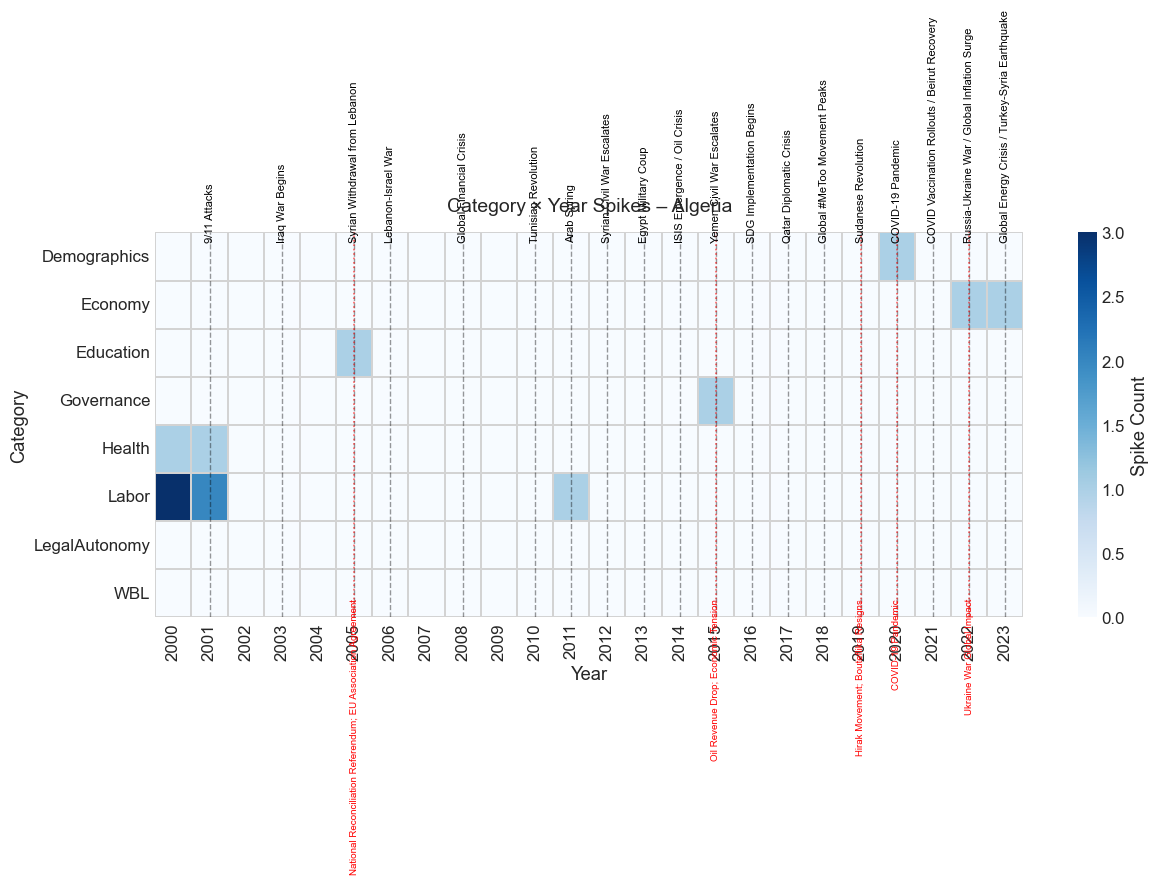

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_44846/578684681.py:83: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: ../worldbank_tableau_project/outputs/event_overlay/Algeria_dips_heatmap.png


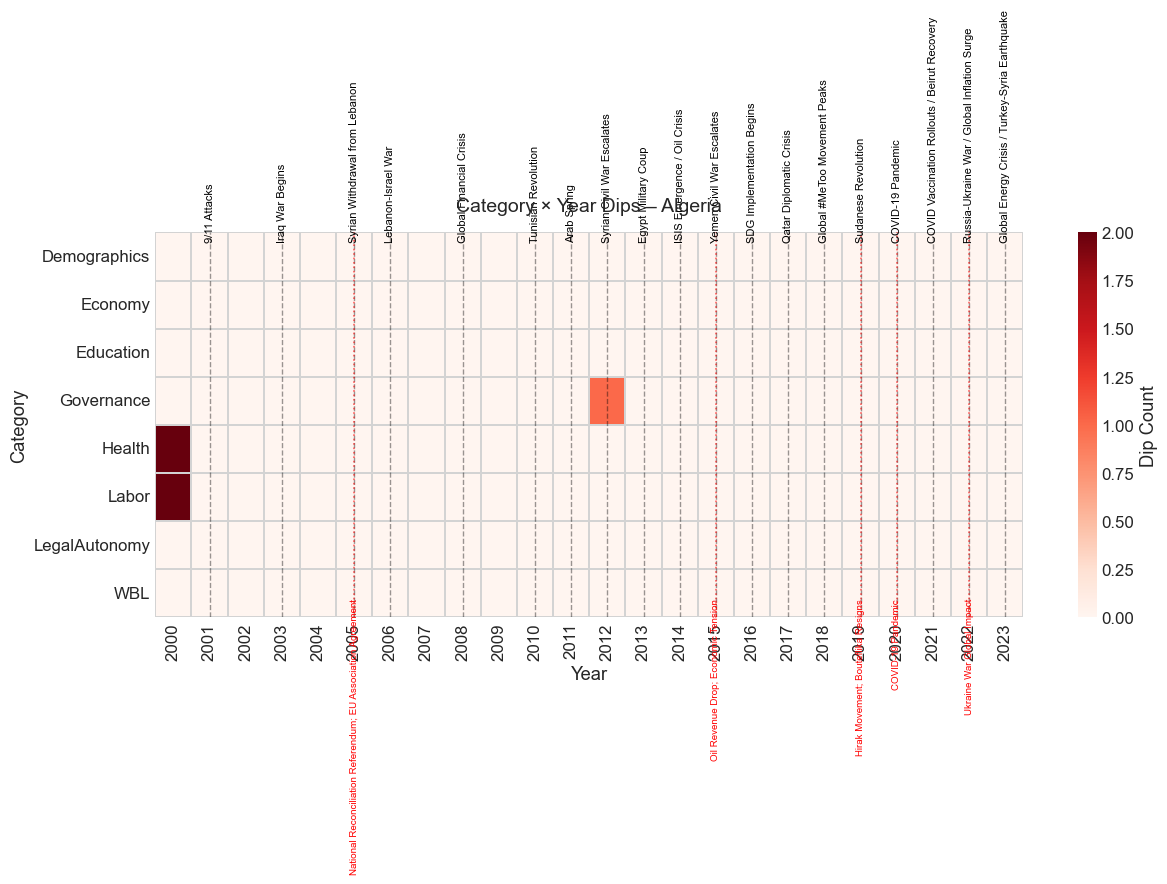

Saved: ../worldbank_tableau_project/outputs/event_overlay/Bahrain_spikes_heatmap.png


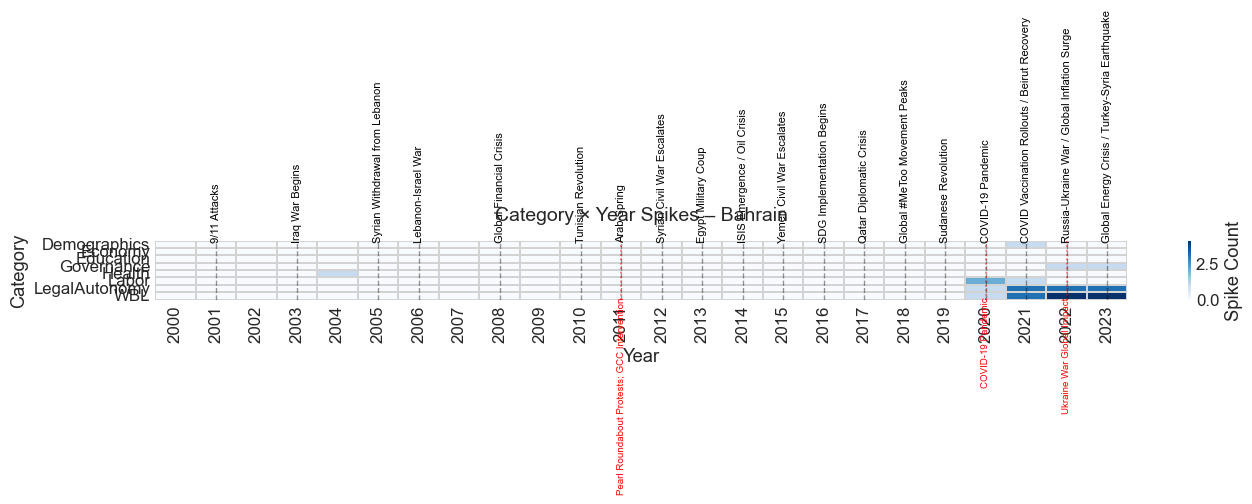

Saved: ../worldbank_tableau_project/outputs/event_overlay/Bahrain_dips_heatmap.png


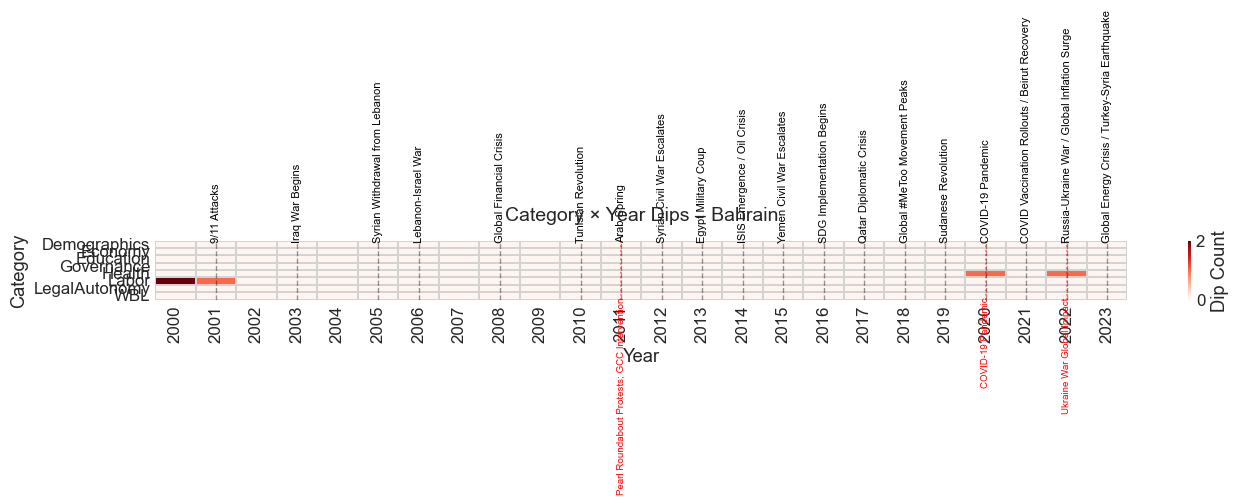

Saved: ../worldbank_tableau_project/outputs/event_overlay/Egypt_Arab_Rep._spikes_heatmap.png


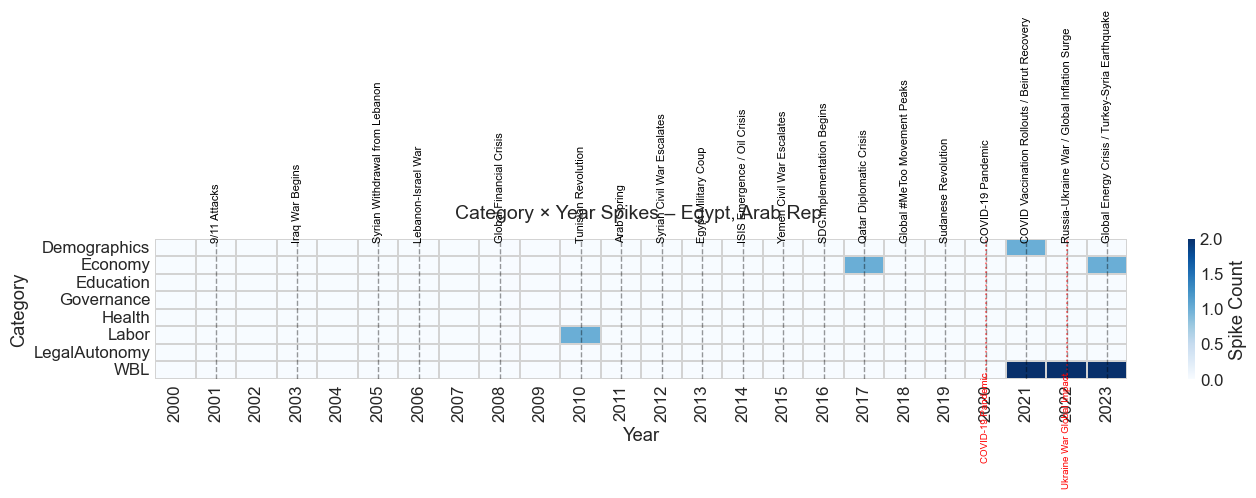

Saved: ../worldbank_tableau_project/outputs/event_overlay/Egypt_Arab_Rep._dips_heatmap.png


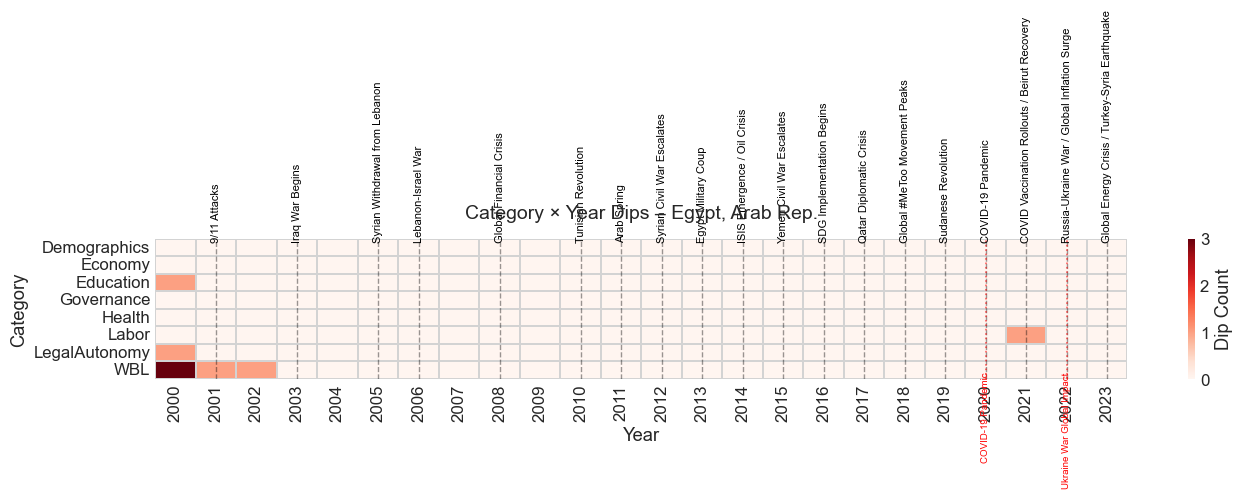

Saved: ../worldbank_tableau_project/outputs/event_overlay/Iran_Islamic_Rep._spikes_heatmap.png


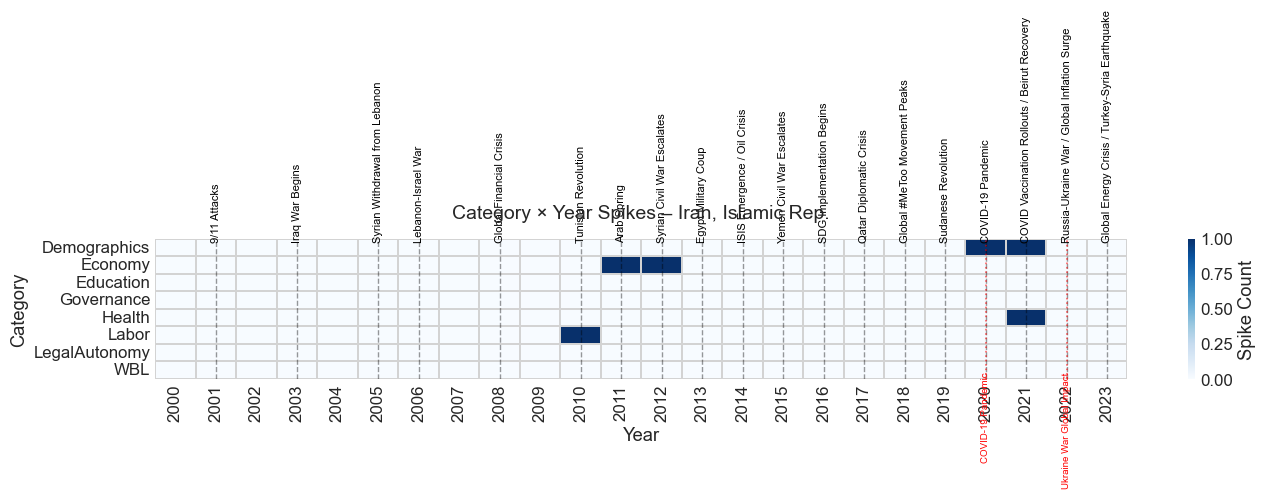

Saved: ../worldbank_tableau_project/outputs/event_overlay/Iran_Islamic_Rep._dips_heatmap.png


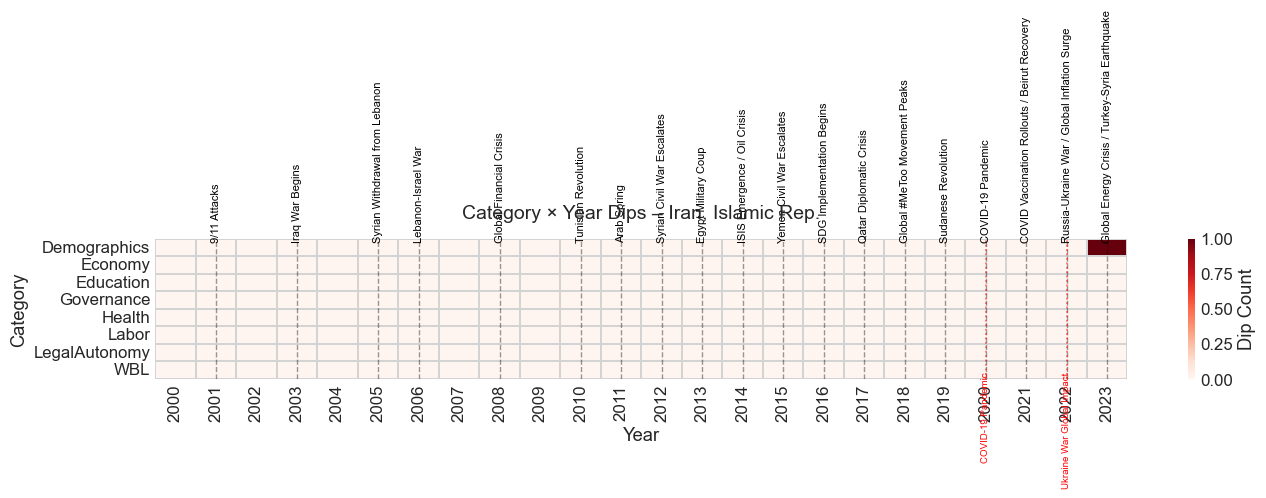

Saved: ../worldbank_tableau_project/outputs/event_overlay/Iraq_spikes_heatmap.png


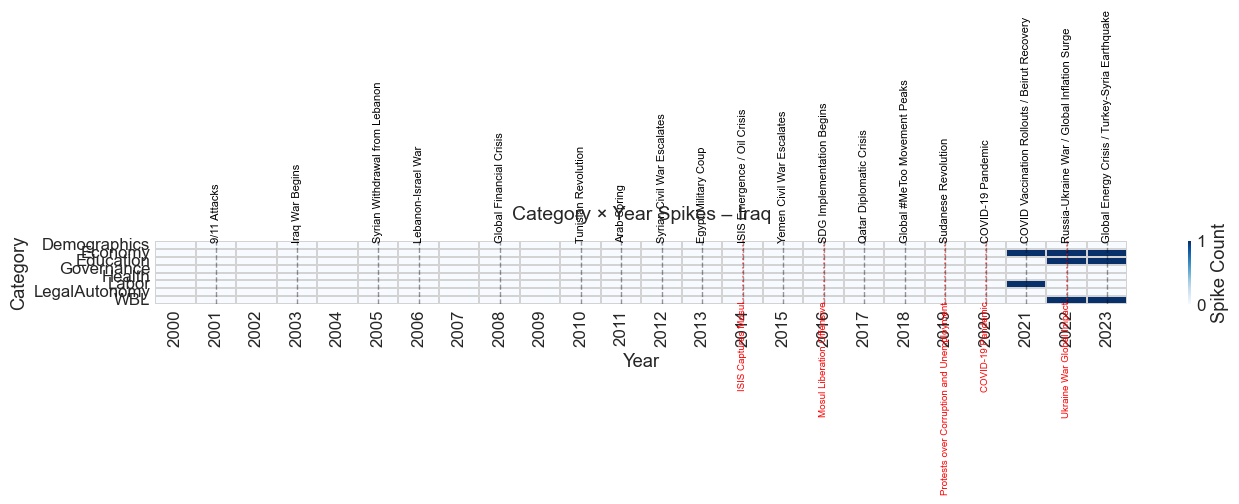

Saved: ../worldbank_tableau_project/outputs/event_overlay/Iraq_dips_heatmap.png


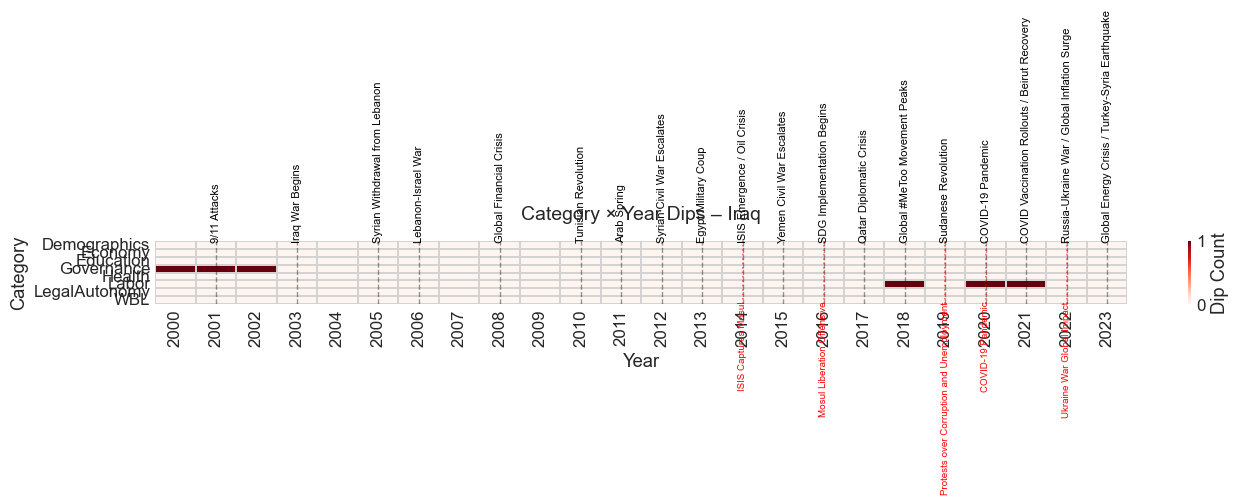

Saved: ../worldbank_tableau_project/outputs/event_overlay/Jordan_spikes_heatmap.png


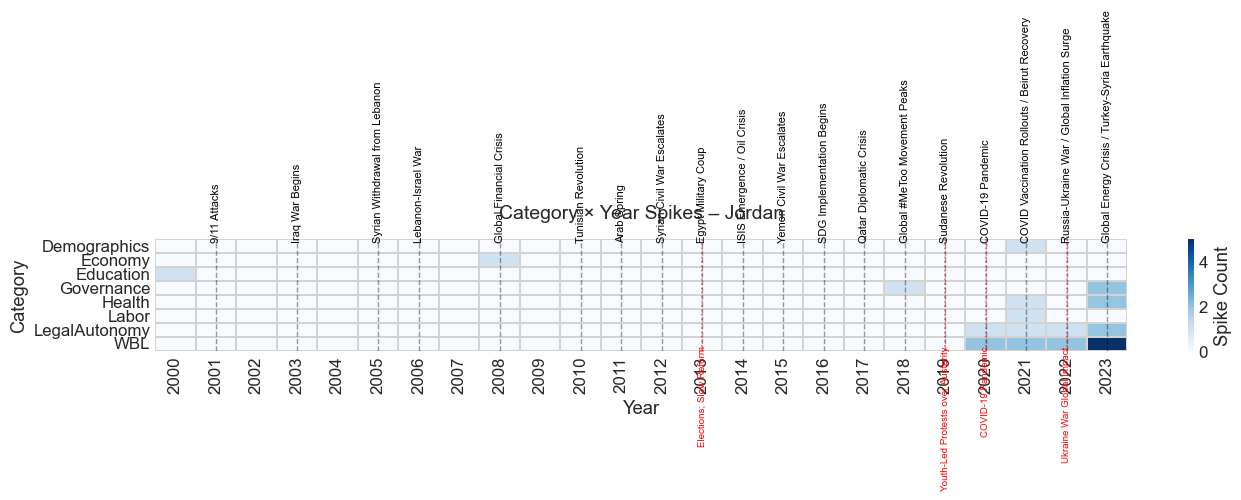

Saved: ../worldbank_tableau_project/outputs/event_overlay/Jordan_dips_heatmap.png


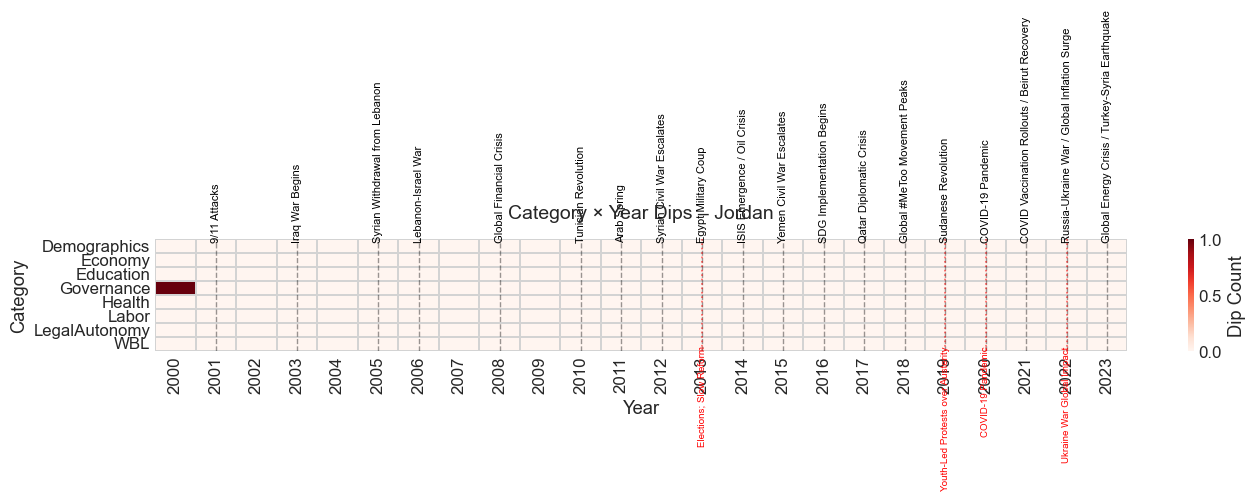

Saved: ../worldbank_tableau_project/outputs/event_overlay/Kuwait_spikes_heatmap.png


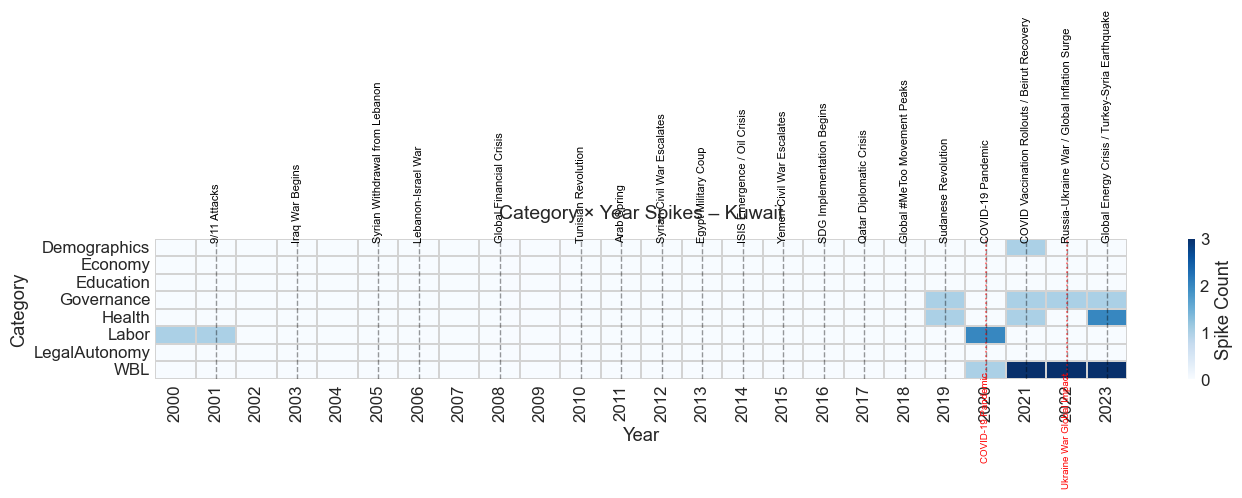

Saved: ../worldbank_tableau_project/outputs/event_overlay/Kuwait_dips_heatmap.png


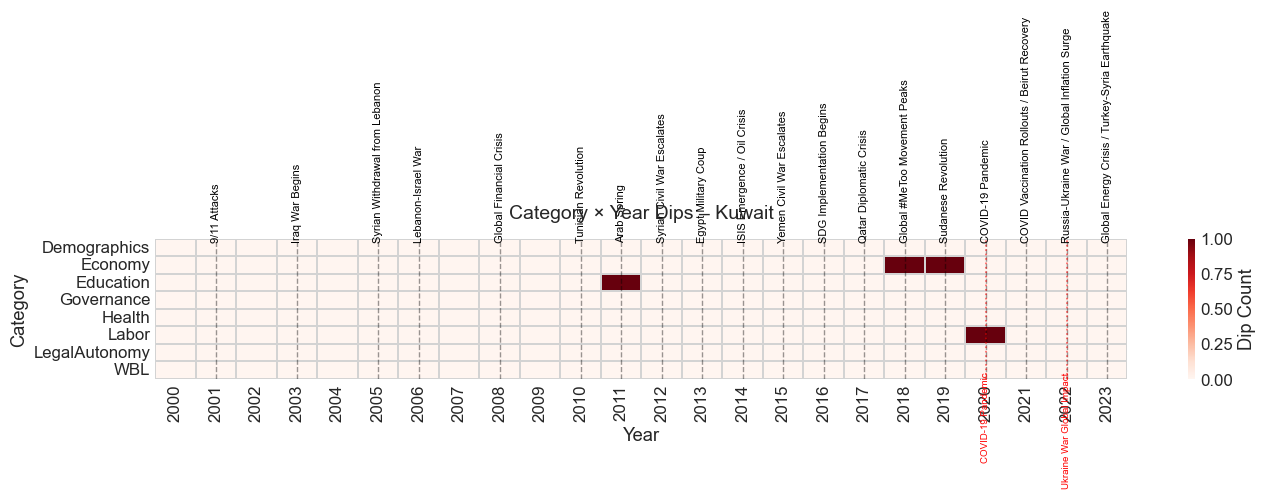

Saved: ../worldbank_tableau_project/outputs/event_overlay/Lebanon_spikes_heatmap.png


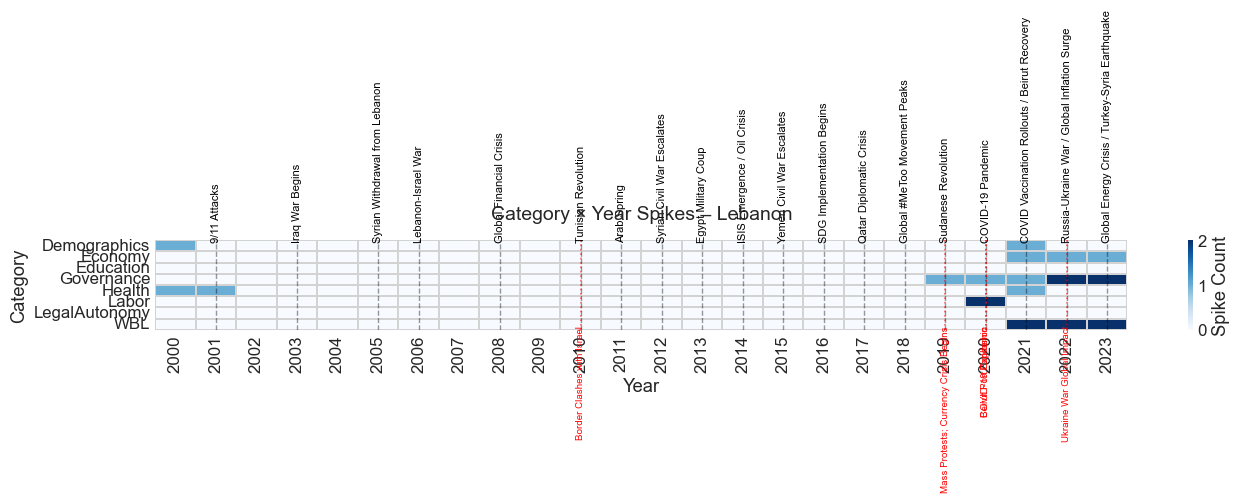

Saved: ../worldbank_tableau_project/outputs/event_overlay/Lebanon_dips_heatmap.png


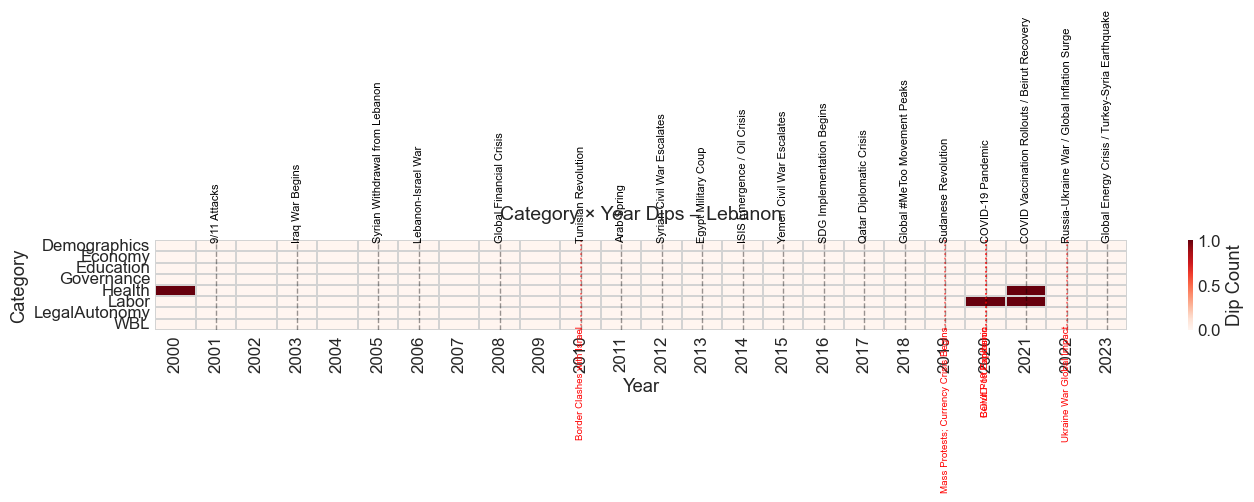

Saved: ../worldbank_tableau_project/outputs/event_overlay/Libya_spikes_heatmap.png


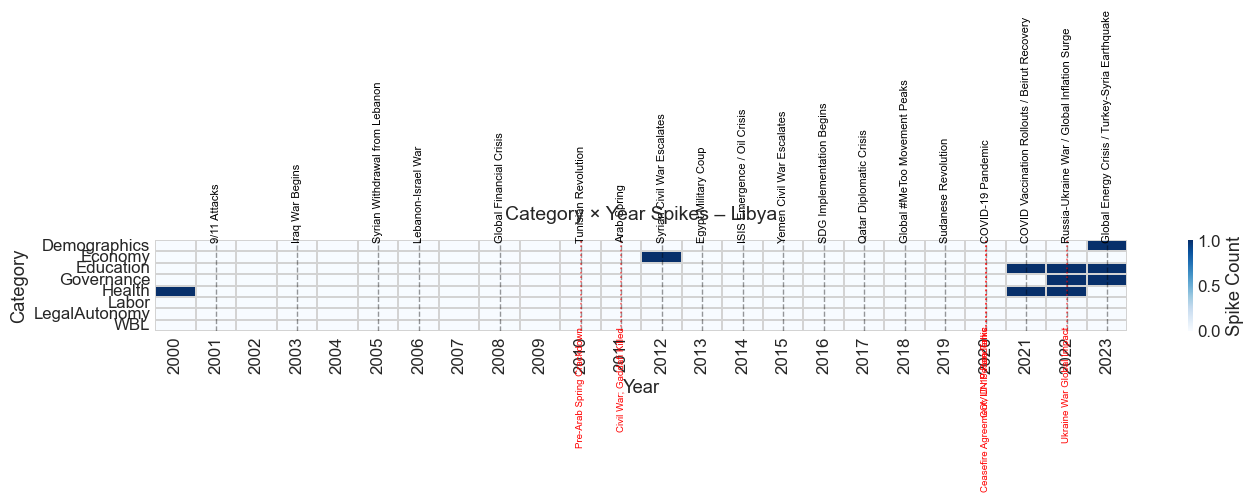

Saved: ../worldbank_tableau_project/outputs/event_overlay/Libya_dips_heatmap.png


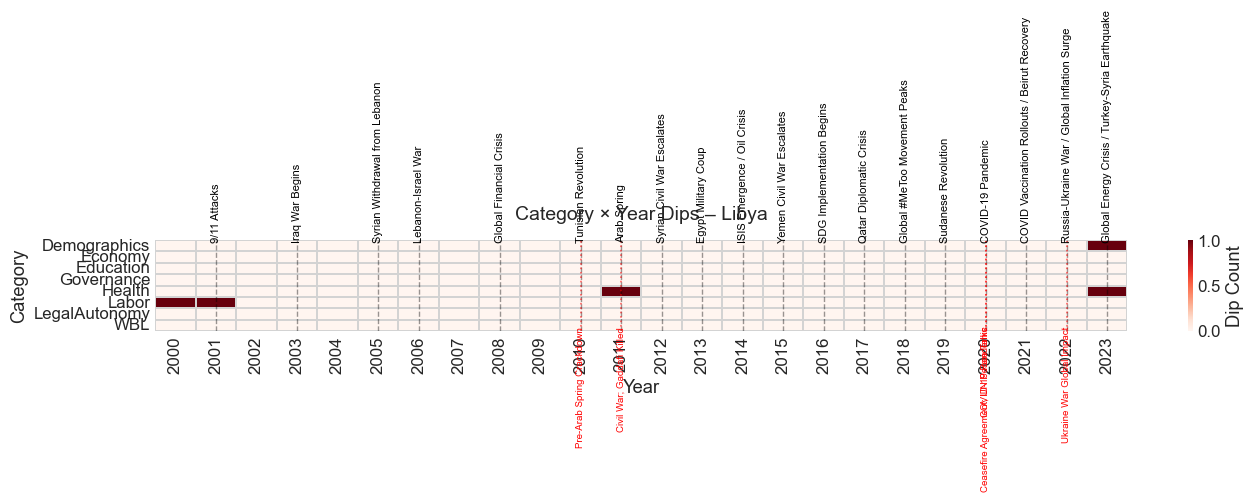

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_44846/578684681.py:83: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: ../worldbank_tableau_project/outputs/event_overlay/Morocco_spikes_heatmap.png


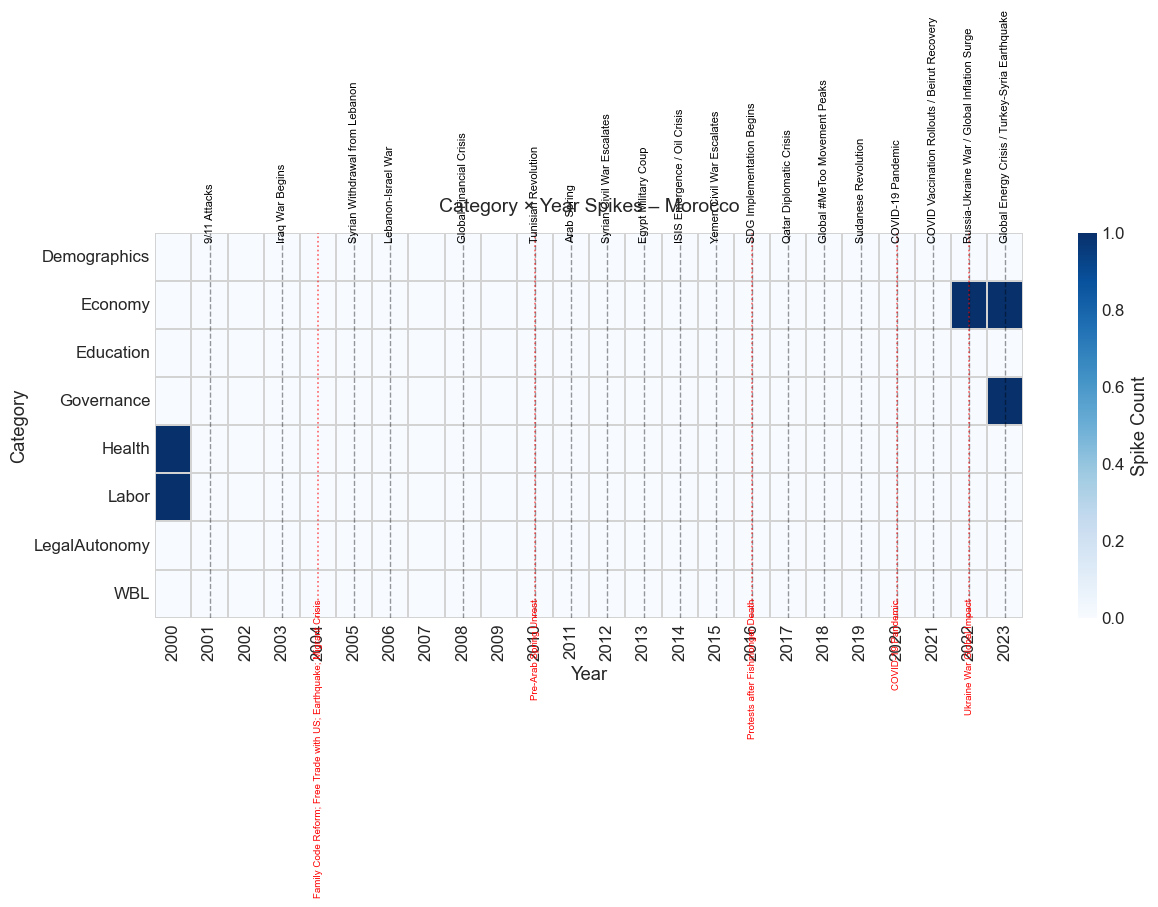

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_44846/578684681.py:83: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved: ../worldbank_tableau_project/outputs/event_overlay/Morocco_dips_heatmap.png


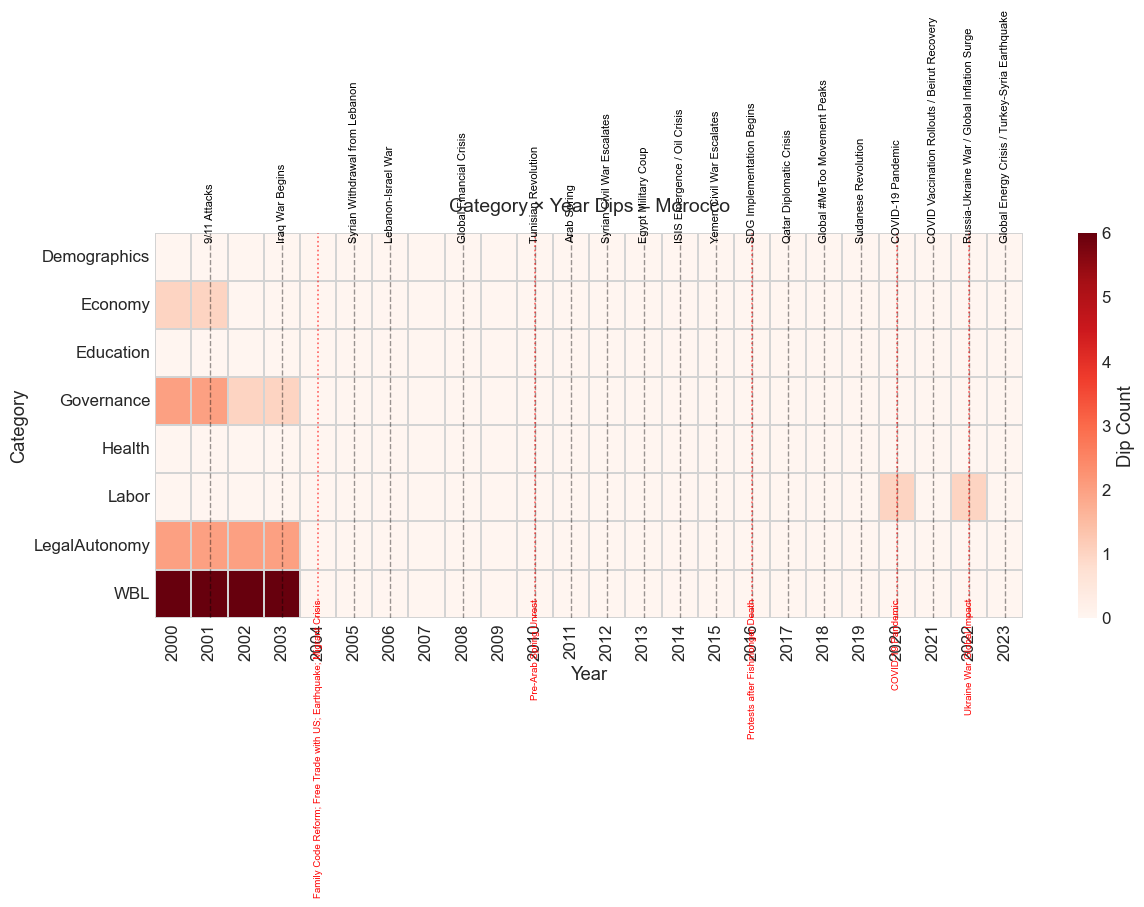

Saved: ../worldbank_tableau_project/outputs/event_overlay/Oman_spikes_heatmap.png


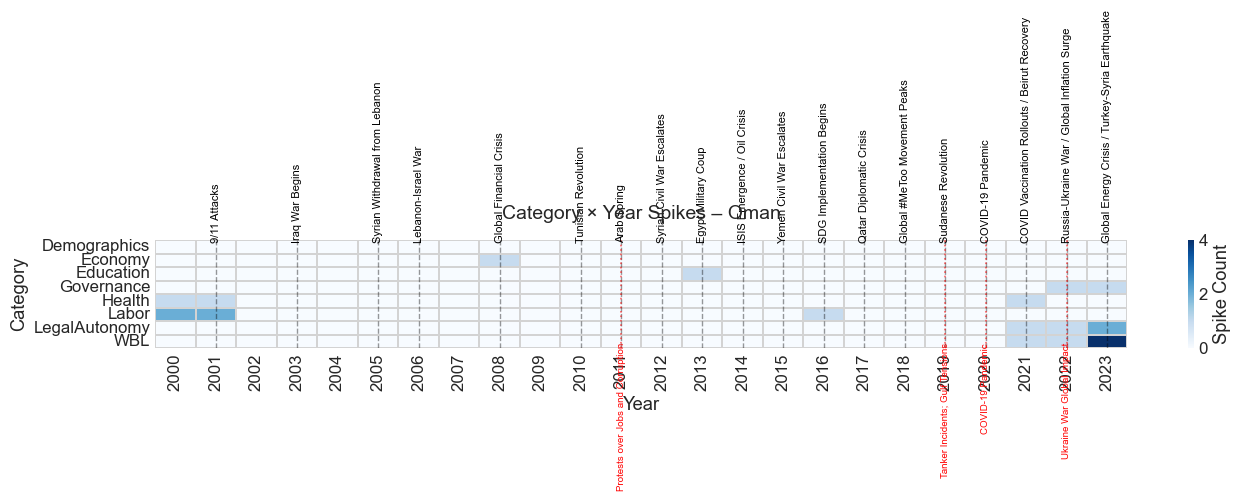

Saved: ../worldbank_tableau_project/outputs/event_overlay/Oman_dips_heatmap.png


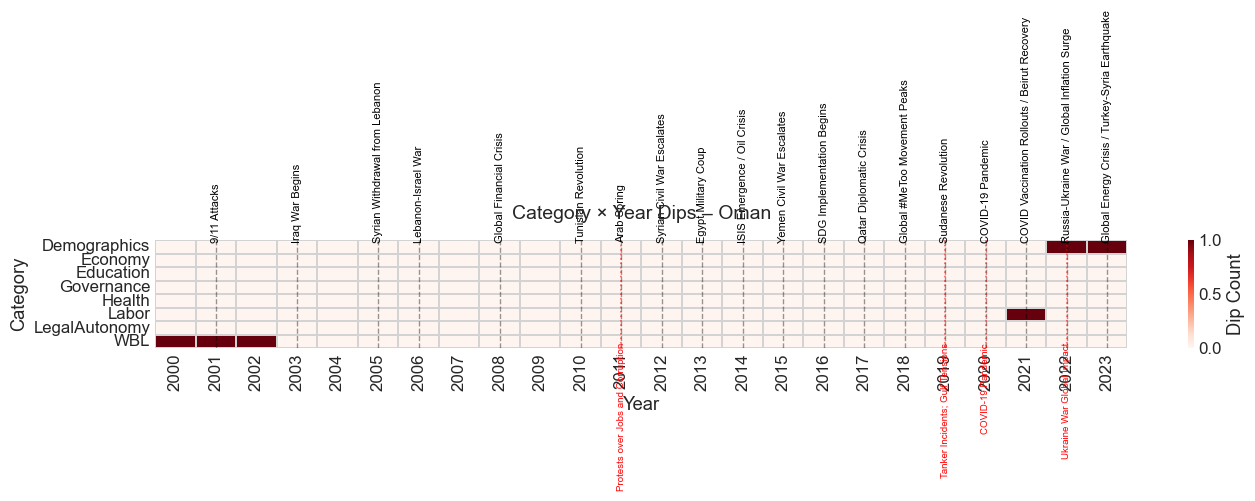

Saved: ../worldbank_tableau_project/outputs/event_overlay/Qatar_spikes_heatmap.png


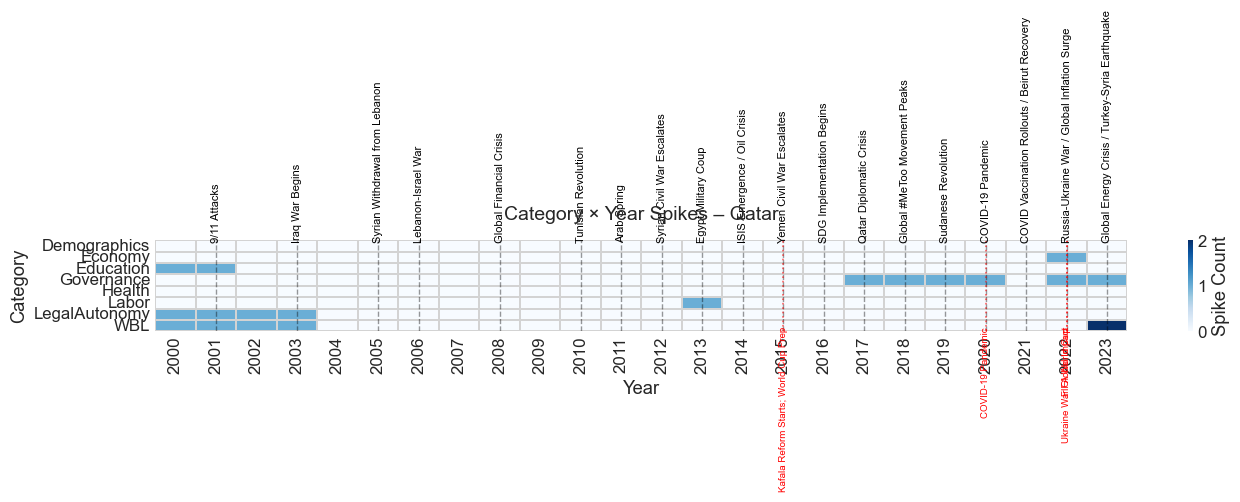

Saved: ../worldbank_tableau_project/outputs/event_overlay/Qatar_dips_heatmap.png


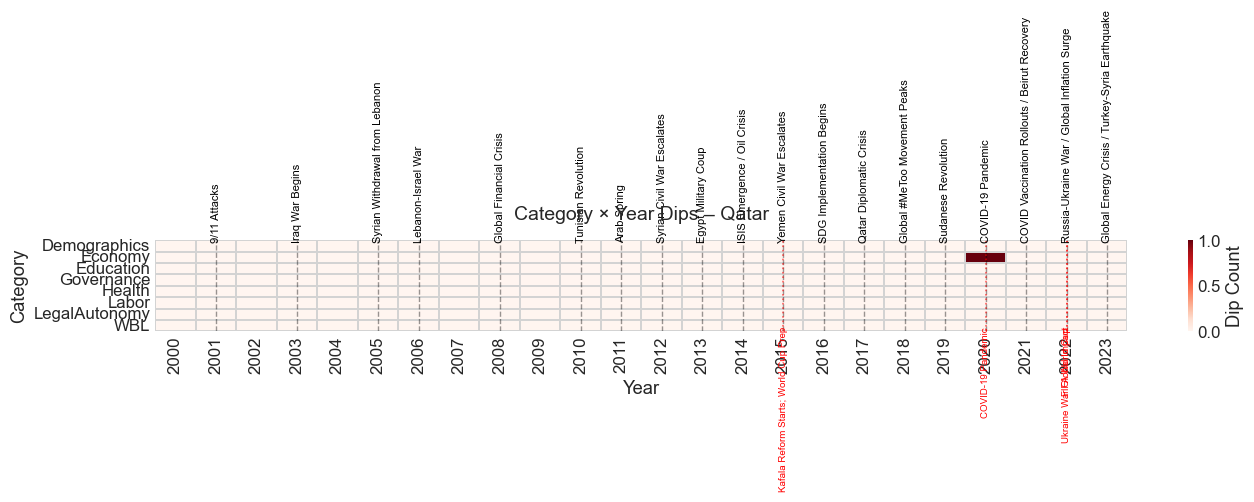

Saved: ../worldbank_tableau_project/outputs/event_overlay/Saudi_Arabia_spikes_heatmap.png


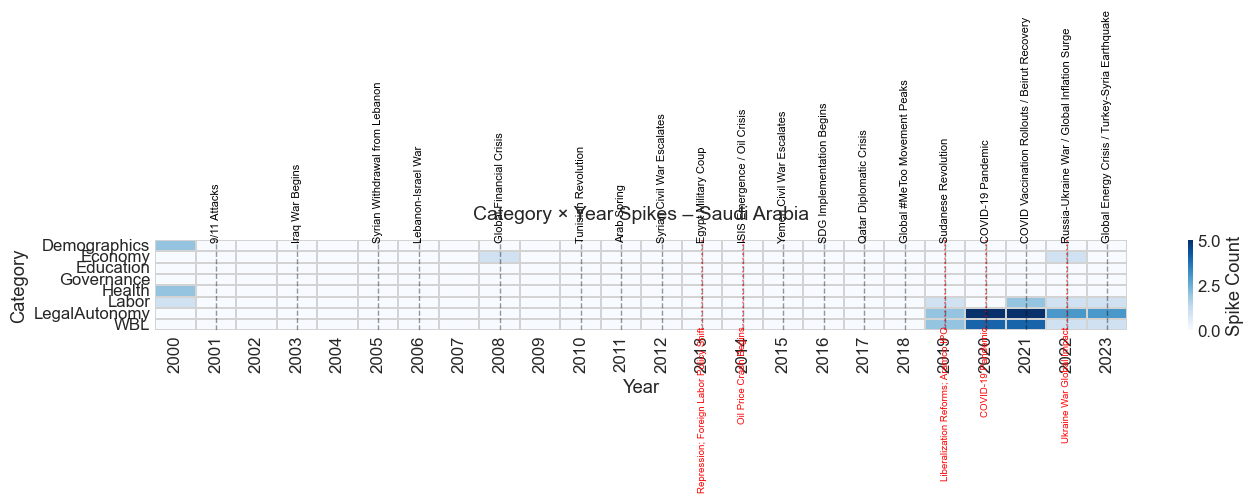

Saved: ../worldbank_tableau_project/outputs/event_overlay/Saudi_Arabia_dips_heatmap.png


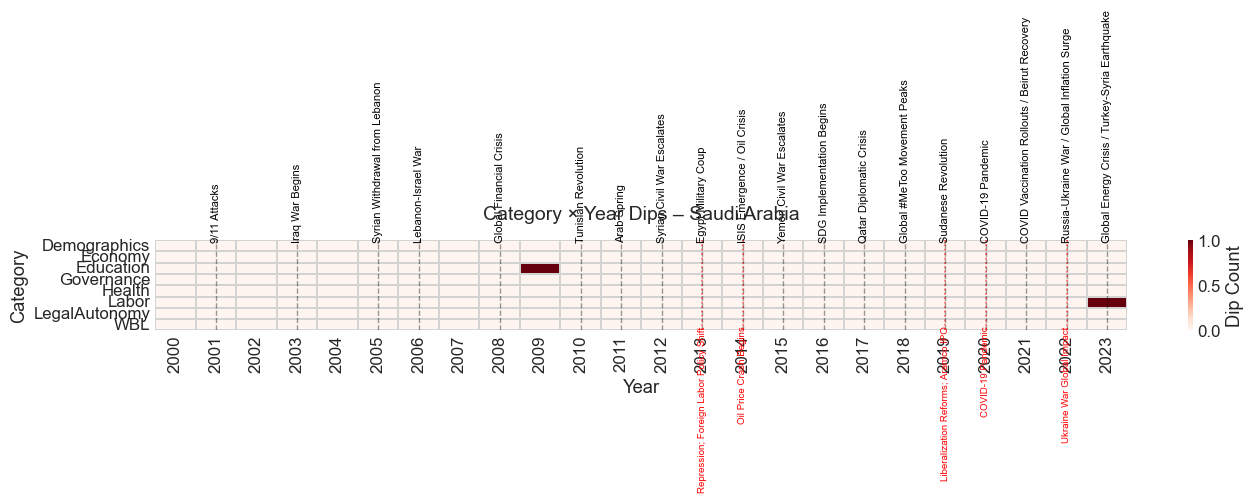

Saved: ../worldbank_tableau_project/outputs/event_overlay/Syrian_Arab_Republic_spikes_heatmap.png


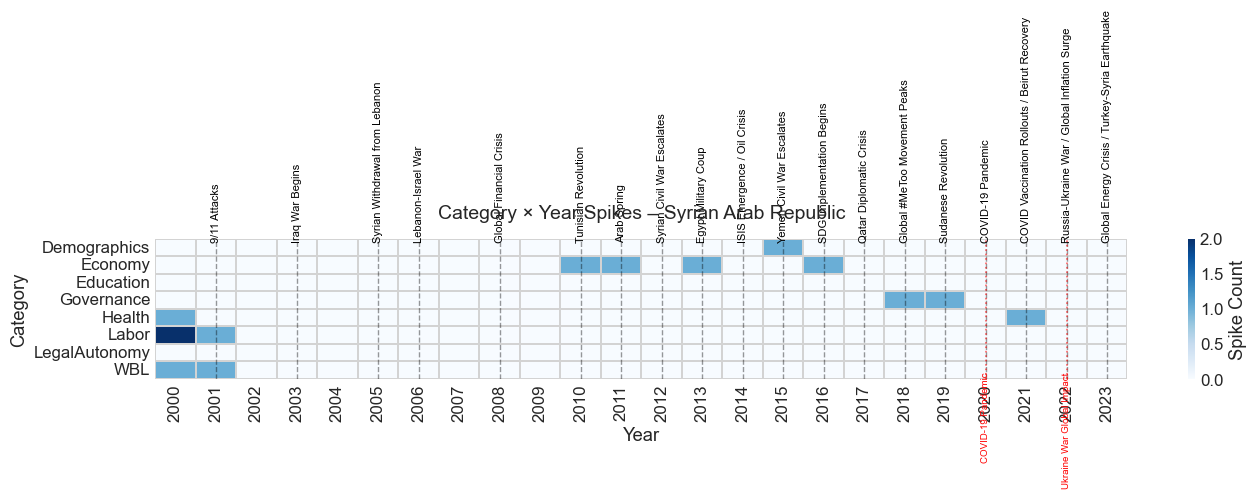

Saved: ../worldbank_tableau_project/outputs/event_overlay/Syrian_Arab_Republic_dips_heatmap.png


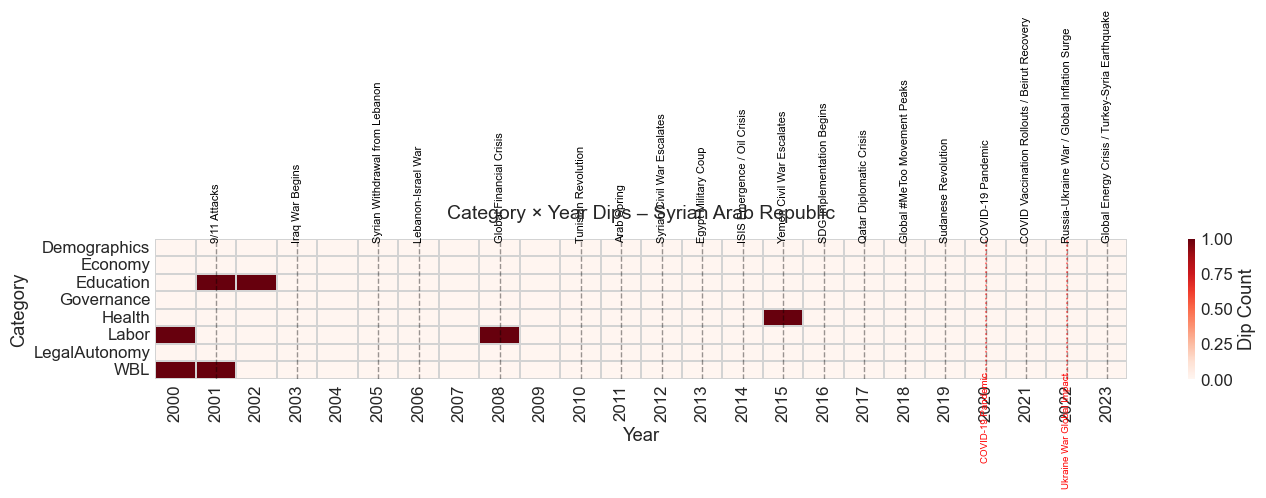

Saved: ../worldbank_tableau_project/outputs/event_overlay/Tunisia_spikes_heatmap.png


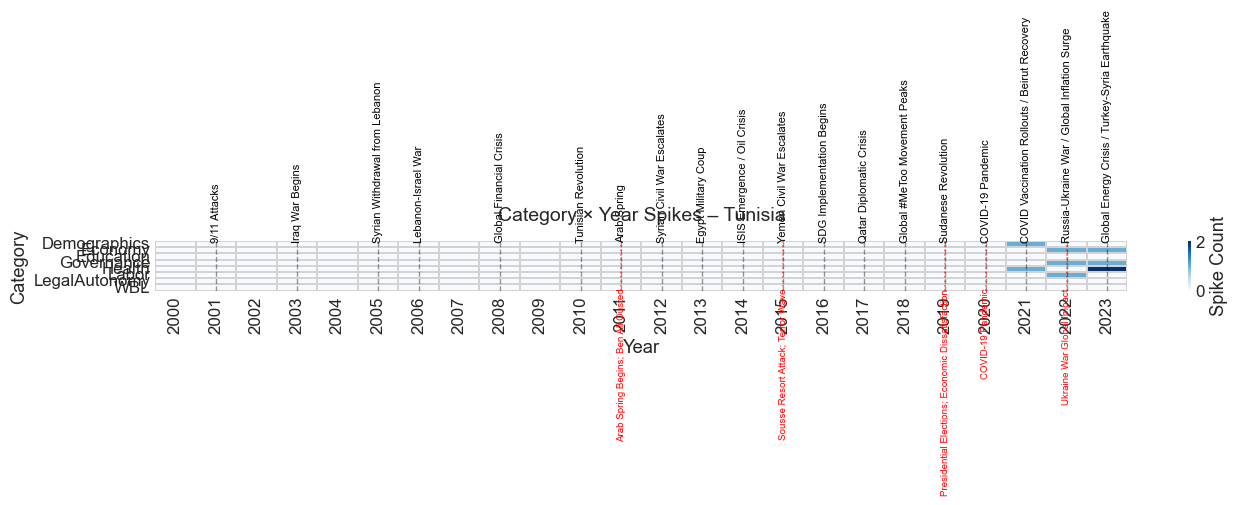

Saved: ../worldbank_tableau_project/outputs/event_overlay/Tunisia_dips_heatmap.png


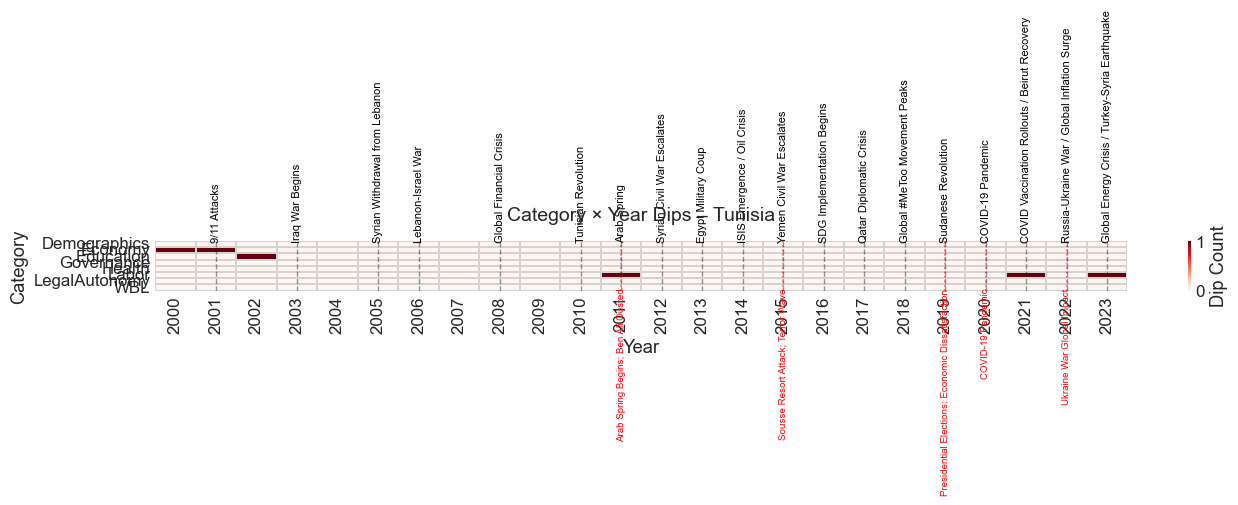

Saved: ../worldbank_tableau_project/outputs/event_overlay/United_Arab_Emirates_spikes_heatmap.png


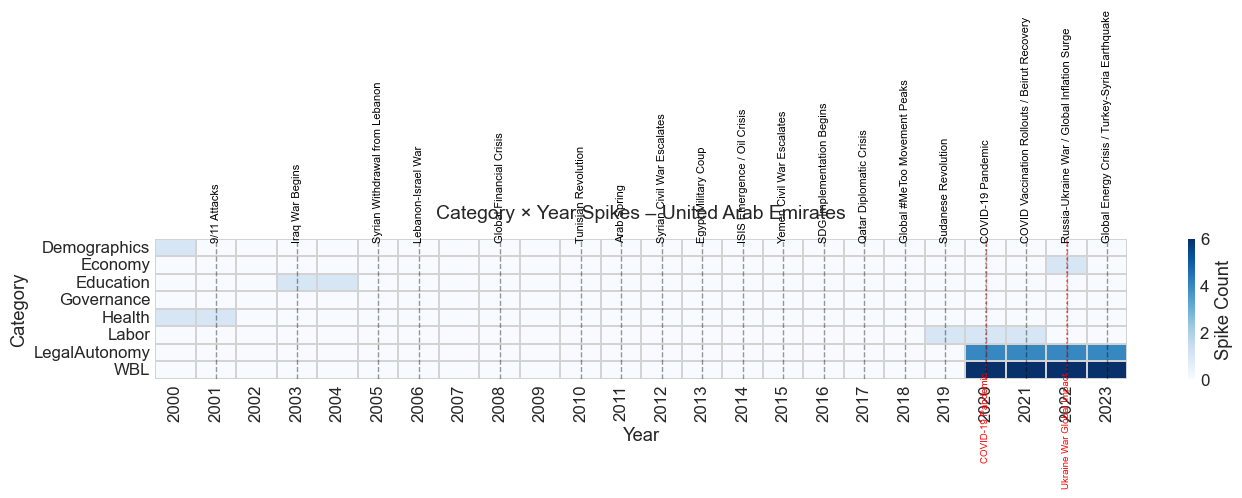

Saved: ../worldbank_tableau_project/outputs/event_overlay/United_Arab_Emirates_dips_heatmap.png


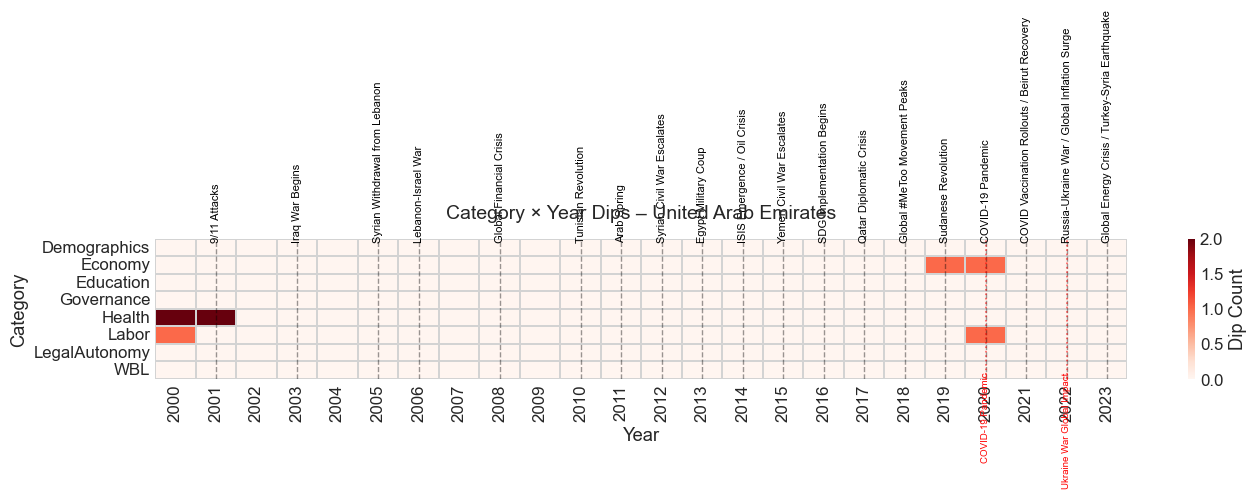

Saved: ../worldbank_tableau_project/outputs/event_overlay/West_Bank_and_Gaza_spikes_heatmap.png


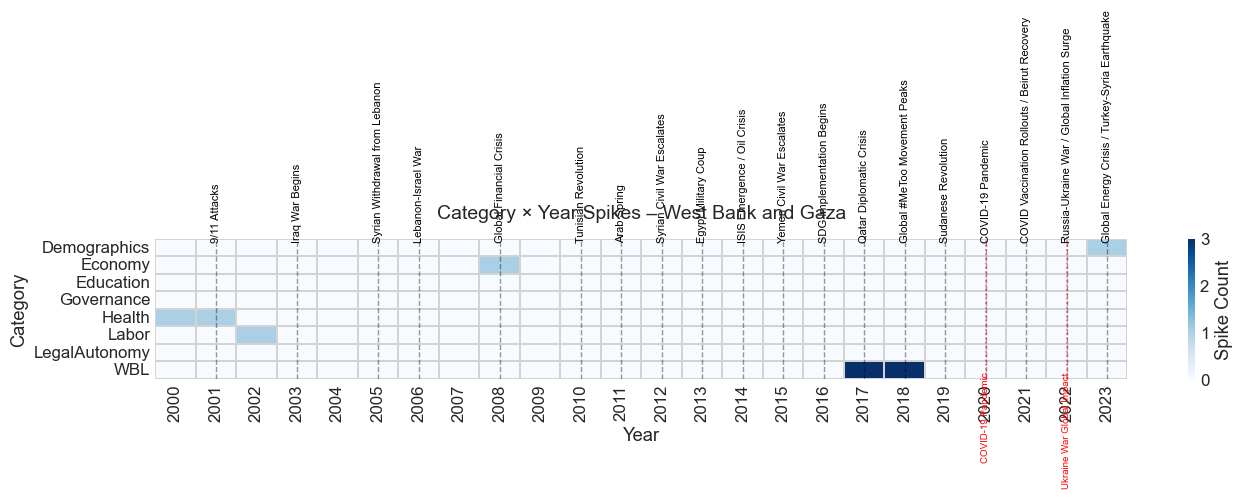

Saved: ../worldbank_tableau_project/outputs/event_overlay/West_Bank_and_Gaza_dips_heatmap.png


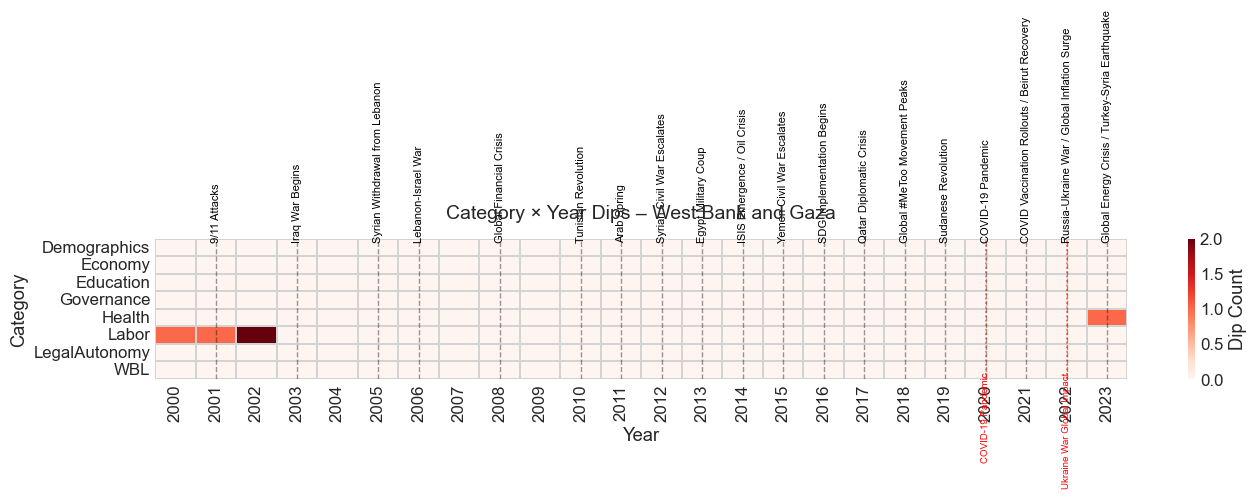

Saved: ../worldbank_tableau_project/outputs/event_overlay/Yemen_Rep._spikes_heatmap.png


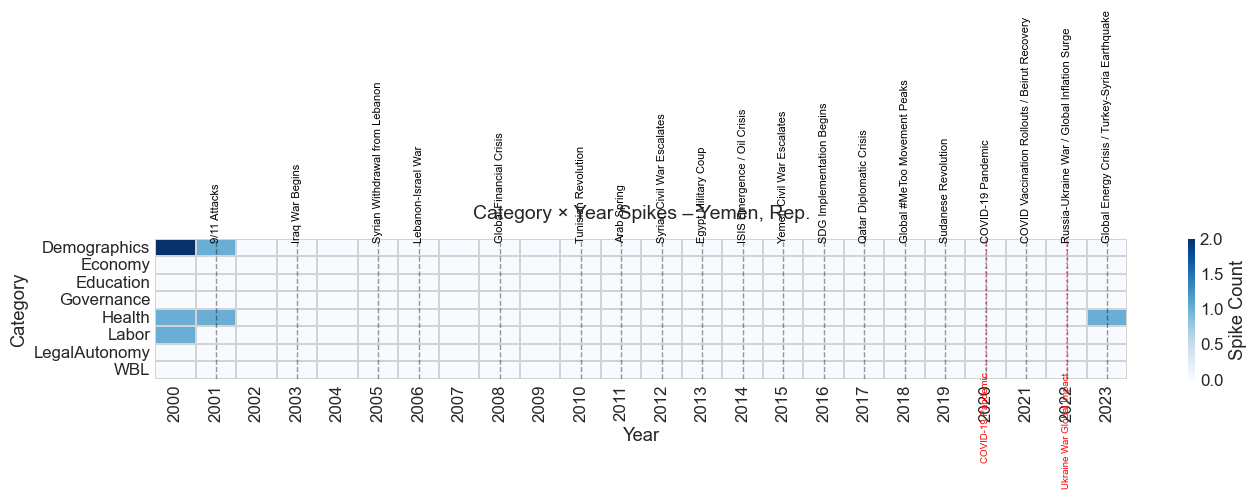

Saved: ../worldbank_tableau_project/outputs/event_overlay/Yemen_Rep._dips_heatmap.png


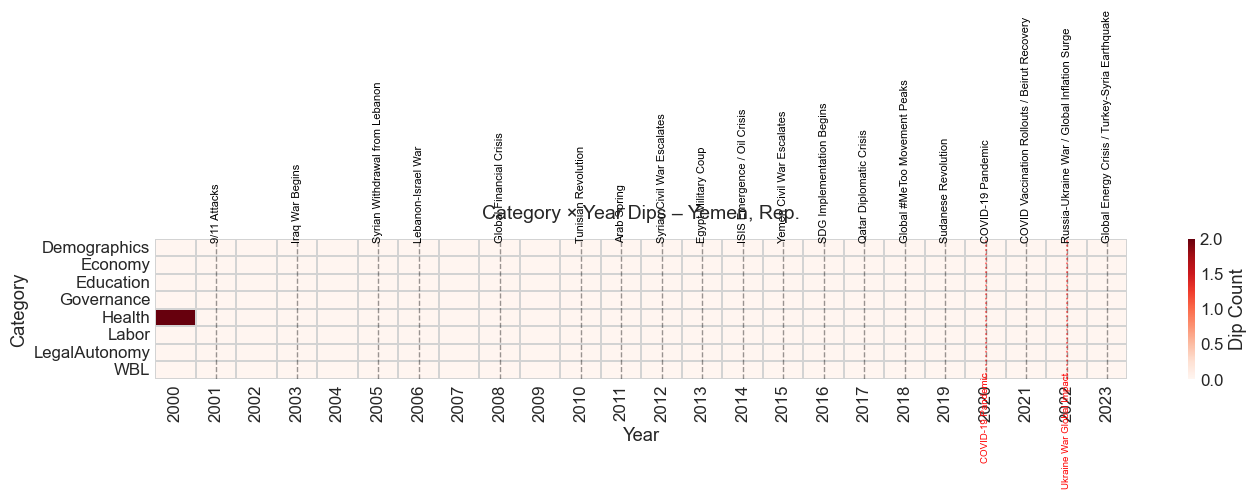

In [70]:
countries = sorted(df["country_name"].unique())

for country in countries:
    
    # 1️⃣ Spikes
    spike_file = os.path.join(
        OUTPUT_DIR,
        f"{country.replace(',', '').replace(' ', '_')}_spikes_heatmap.png"
    )
    
    plot_country_cat_year_heatmap(
        df,
        country,
        value_col="spike",
        title_prefix="Category × Year Spikes",
        cmap="Blues",
        save_path=spike_file
    )
    
    # 2️⃣ Dips
    dip_file = os.path.join(
        OUTPUT_DIR,
        f"{country.replace(',', '').replace(' ', '_')}_dips_heatmap.png"
    )
    
    plot_country_cat_year_heatmap(
        df,
        country,
        value_col="dip",
        title_prefix="Category × Year Dips",
        cmap="Reds",
        save_path=dip_file
    )


## Country Summary Table

In [71]:
def generate_country_summary(df, country):
    """
    Creates a yearly summary table for a given country:
    - spike count per category
    - dip count per category
    - global events
    - country-specific events
    """
    
    cdf = df[df["country_name"] == country].copy()

    # Aggregate spikes/dips by year & category
    summary = (
        cdf.groupby(["year", "category"])
           .agg(
                spikes=("spike", "sum"),
                dips=("dip", "sum"),
                global_event=("event_global", "max"),
                country_event=("event_country", "max")
           )
           .reset_index()
    )

    # Map event labels
    summary["global_event_label"] = summary["year"].map(SHORT_EVENTS).fillna("")
    
    summary["country_event_label"] = summary.apply(
        lambda row: COUNTRY_YEAR_EVENTS.get((country, row["year"]), ""),
        axis=1
    )

    return summary


In [72]:
SUMMARY_DIR = os.path.join(OUTPUT_DIR, "country_summaries")
os.makedirs(SUMMARY_DIR, exist_ok=True)

for country in countries:
    summary = generate_country_summary(df, country)

    file_path = os.path.join(
        SUMMARY_DIR,
        f"{country.replace(',', '').replace(' ', '_')}_summary.csv"
    )

    summary.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")


Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Algeria_summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Bahrain_summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Egypt_Arab_Rep._summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Iran_Islamic_Rep._summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Iraq_summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Jordan_summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Kuwait_summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Lebanon_summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Libya_summary.csv
Saved: ../worldbank_tableau_project/outputs/event_overlay/country_summaries/Morocco_summary.csv
Saved: ../worldbank_tableau_p

In [73]:
from IPython.display import display

summary = generate_country_summary(df, "Algeria")

# Optional pretty sorting:
summary = summary.sort_values(["year", "category"])

display(summary.head(20))


,year,category,spikes,dips,global_event,country_event,global_event_label,country_event_label
0,2000,Demographics,0,0,0,0,,
1,2000,Economy,0,0,0,0,,
2,2000,Education,0,0,0,0,,
3,2000,Governance,0,0,0,0,,
4,2000,Health,1,2,0,0,,
5,2000,Labor,3,2,0,0,,
6,2000,LegalAutonomy,0,0,0,0,,
7,2000,WBL,0,0,0,0,,
8,2001,Demographics,0,0,1,0,,
9,2001,Economy,0,0,1,0,,


In [ ]:
summary = generate_country_summary(df, "Algeria")

# Optional pretty sorting:
summary = summary.sort_values(["year", "category"])

display(summary.head(20))

## A Combined Country Report

### 1- Imports & Global Settings

In [154]:
from reportlab.platypus import (
    SimpleDocTemplate, Table, TableStyle,
    Paragraph, Spacer, Image, PageBreak
)
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet

styles = getSampleStyleSheet()
NORMAL = styles["Normal"]
HEADER = styles["Heading5"]

In [166]:
country_cluster_label = (
    df[["country_name", "Cluster_Name"]]
    .drop_duplicates()
    .set_index("country_name")["Cluster_Name"]
    .to_dict()
)


### 2- Helper Utilities

In [156]:
def clean_event_string(text, max_items=2):
    if pd.isna(text) or str(text).strip() == "":
        return ""
    parts = [p.strip() for p in str(text).split(";") if p.strip()]
    unique = list(dict.fromkeys(parts))
    if len(unique) <= max_items:
        return ", ".join(unique)
    return ", ".join(unique[:max_items]) + " …"


In [157]:
def df_to_platypus_table(df, long_text_cols=None, col_widths=None):
    if long_text_cols is None:
        long_text_cols = []

    data = []
    header_row = [Paragraph(f"<b>{col}</b>", HEADER) for col in df.columns]
    data.append(header_row)

    for _, row in df.iterrows():
        row_cells = []
        for col in df.columns:
            val = "" if pd.isna(row[col]) else row[col]
            if col in long_text_cols:
                row_cells.append(Paragraph(str(val), NORMAL))
            else:
                row_cells.append(str(val))
        data.append(row_cells)

    table = Table(data, colWidths=col_widths, repeatRows=1)

    style = TableStyle([
        ("GRID", (0, 0), (-1, -1), 0.25, colors.grey),
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#E0E0E0")),
        ("VALIGN", (0, 0), (-1, -1), "TOP"),
    ])

    # Row striping
    for i in range(1, len(data)):
        color = colors.whitesmoke if i % 2 == 0 else colors.white
        style.add("BACKGROUND", (0, i), (-1, i), color)

    table.setStyle(style)
    return table


### 3- Plot Generators (Saved Silently)

In [158]:
def save_country_heatmap(df, country, value_col, cmap, save_path, title_prefix):
    """Generate and save heatmap silently (no plt.show())."""

    fig, ax = plt.subplots(figsize=(18, 6))
    df_country = df[df["country_name"] == country]

    pivot = df_country.pivot_table(
        index="category",
        columns="year",
        values=value_col,
        aggfunc="sum",
        fill_value=0
    )

    sns.heatmap(
        pivot,
        cmap=cmap,
        linewidths=0.3,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": value_col},
        vmin=0
    )

    ax.set_title(f"{title_prefix} — {country}", fontsize=14)

    # Save only
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


In [159]:
def save_country_trendlines(df, country, save_total, save_cat_prefix):
    dfc = df[df["country_name"] == country]

    yearly = dfc.groupby("year").agg(
        spikes=("spike", "sum"),
        dips=("dip", "sum")
    ).reset_index()

    # --- Total trendlines ---
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(yearly["year"], yearly["spikes"], label="Spikes", color="blue")
    ax.plot(yearly["year"], yearly["dips"], label="Dips", color="red")
    ax.set_title(f"Total Spikes & Dips — {country}")
    ax.legend()
    fig.savefig(save_total, dpi=300, bbox_inches="tight")
    plt.close(fig)

    # --- Category trendlines ---
    categories = ["Governance", "WBL", "Health", "Labor"]
    for cat in categories:
        dfc_cat = dfc[dfc["category"] == cat]
        yearly_cat = dfc_cat.groupby("year")[["spike", "dip"]].sum().reset_index()

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(yearly_cat["year"], yearly_cat["spike"], label="Spikes", color="blue")
        ax.plot(yearly_cat["year"], yearly_cat["dip"], label="Dips", color="red")
        ax.set_title(f"{cat} Volatility — {country}")
        ax.legend()

        fig.savefig(f"{save_cat_prefix}_{cat}.png", dpi=300, bbox_inches="tight")
        plt.close(fig)



### 4- Summary Table Builders

In [160]:
def build_country_summary_df(df, country):
    dfc = df[df["country_name"] == country].copy()

    dfc["has_event"] = (
        (dfc["event_global"] == 1) |
        (dfc["event_country"] == 1) |
        (dfc["spike"] == 1) |
        (dfc["dip"] == 1)
    )
    dfc = dfc[dfc["has_event"]]

    dfc["global_event_clean"] = dfc["global_event_name"].apply(clean_event_string)
    dfc["country_event_clean"] = dfc["country_event_name"].apply(clean_event_string)
    dfc["short_event_clean"] = dfc["short_event"].apply(clean_event_string)

    return dfc[[
        "year", "category", "spike", "dip",
        "event_global", "event_country",
        "global_event_clean", "country_event_clean", "short_event_clean"
    ]].sort_values("year").reset_index(drop=True)


In [161]:
def build_category_summary_df(df, country):
    dfc = df[df["country_name"] == country]

    cat = dfc.groupby("category").agg(
        total_spikes=("spike", "sum"),
        total_dips=("dip", "sum")
    ).reset_index()

    cat["net_change"] = cat["total_spikes"] - cat["total_dips"]
    return cat.sort_values("total_spikes", ascending=False)


### 5- Country Narrative Builder

In [162]:
def generate_country_narrative(df, country, cluster_label):
    dfc = df[df["country_name"] == country]

    # basic stats
    peak_spike_year = dfc.groupby("year")["spike"].sum().idxmax()
    peak_dip_year = dfc.groupby("year")["dip"].sum().idxmax()
    wbl_spikes = dfc[dfc["category"] == "WBL"]["spike"].sum()
    gov_dips = dfc[dfc["category"] == "Governance"]["dip"].sum()

    narrative = f"""
{country} exhibits a development pattern consistent with its assigned 
Trajectory Cluster: **{cluster_label}**.

Key observations include:

• **Peak volatility** appears in {peak_spike_year} (spikes) 
  and {peak_dip_year} (dips), driven primarily by Governance and Labor categories.

• **WBL indicators** recorded {wbl_spikes} spike events, reflecting 
  legal/social reform episodes.

• **Governance-related dips** total {gov_dips}, matching years of 
  national stress, political turnover, or economic contraction.

• Global shocks such as the **Arab Spring (2011)**, 
  **Oil Crisis (2014–2016)** and **COVID-19 (2020)** show identifiable 
  impact on category-level volatility.

Overall, {country} demonstrates a pattern of:
– Shock sensitivity during crisis periods  
– Resilience in long-term reform trajectories  
– Category-specific structural responses  
    """

    return narrative.strip()


### 6- Premium PDF Creator (Platypus)

In [168]:
def create_country_pdf_platypus(
    country, cluster_label, narrative,
    summary_df, category_df,
    spikes_img, dips_img,
    trends_total_img, trends_cat_prefix,
    save_path
):
    doc = SimpleDocTemplate(save_path, pagesize=A4,
                            leftMargin=40, rightMargin=40,
                            topMargin=50, bottomMargin=40)

    story = []

    # Page 1 — Title
    story.append(Paragraph(f"{country} — Shock & Reform Dynamics Report", styles["Title"]))
    story.append(Paragraph(f"Trajectory Cluster: <b>{cluster_label}</b>", styles["Heading2"]))
    story.append(PageBreak())

    # Page 2 — Narrative
    story.append(Paragraph("Narrative Summary", styles["Heading1"]))
    for para in narrative.split("\n\n"):
        story.append(Paragraph(para, NORMAL))
        story.append(Spacer(1, 8))
    story.append(PageBreak())

    # Page 3 — Summary Table
    story.append(Paragraph("Event–Spike–Dip Summary", styles["Heading1"]))
    story.append(df_to_platypus_table(
        summary_df,
        long_text_cols=["global_event_clean", "country_event_clean", "short_event_clean"],
        col_widths=[30, 60, 25, 25, 25, 25, 120, 120, 100]
    ))
    story.append(PageBreak())

    # Category Summary
    story.append(Paragraph("Category Summary", styles["Heading1"]))
    story.append(df_to_platypus_table(
        category_df,
        col_widths=[90, 60, 60, 60]
    ))
    story.append(PageBreak())

    # Heatmaps
    story.append(Paragraph("Spikes Heatmap", styles["Heading1"]))
    story.append(Image(spikes_img, width=500, height=250))
    story.append(PageBreak())

    story.append(Paragraph("Dips Heatmap", styles["Heading1"]))
    story.append(Image(dips_img, width=500, height=250))
    story.append(PageBreak())

    # Total Trends
    story.append(Paragraph("Total Volatility Trends", styles["Heading1"]))
    story.append(Image(trends_total_img, width=500, height=250))
    story.append(PageBreak())

    # Category Trends
    for cat in ["Governance", "WBL", "Health", "Labor"]:
        img = f"{trends_cat_prefix}_{cat}.png"
        if os.path.exists(img):
            story.append(Paragraph(f"{cat} Trends", styles["Heading1"]))
            story.append(Image(img, width=500, height=250))
            story.append(PageBreak())

    doc.build(story)


### 7-Full Pipeline Loop

In [169]:
PDF_DIR = os.path.join(OUTPUT_DIR, "country_reports_final")
os.makedirs(PDF_DIR, exist_ok=True)


def abs_path(path):
    return os.path.abspath(path)


for country in countries:
    print(f"Generating report for {country}...")

    cluster_label = country_cluster_label.get(country, "Unknown Cluster")
    narrative = generate_country_narrative(df, country, cluster_label)

    # File paths
    
    spikes_img = abs_path(os.path.join(OUTPUT_DIR, f"{country}_spikes.png"))
    dips_img = abs_path(os.path.join(OUTPUT_DIR, f"{country}_dips.png"))
    trends_total_img = abs_path(os.path.join(OUTPUT_DIR, f"{country}_trends.png"))
    trends_cat_prefix = abs_path(os.path.join(OUTPUT_DIR, f"{country}_trends_cat"))
    
    # Save heatmaps
    save_country_heatmap(df, country, "spike", "Blues", spikes_img, "Spikes Heatmap")
    save_country_heatmap(df, country, "dip", "Reds", dips_img, "Dips Heatmap")

    # Save trendlines
    save_country_trendlines(df, country, trends_total_img, trends_cat_prefix)

    # Build tables
    summary_df = build_country_summary_df(df, country)
    category_df = build_category_summary_df(df, country)
    
    pdf_path = abs_path(os.path.join(PDF_DIR, f"{country}_Report.pdf"))


    # Generate PDF
    create_country_pdf_platypus(
        country, cluster_label, narrative,
        summary_df, category_df,
        spikes_img, dips_img,
        trends_total_img, trends_cat_prefix,
        pdf_path
    )

    print(f"Saved → {pdf_path}\n")


Generating report for Algeria...
Saved → /Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/event_overlay/country_reports_final/Algeria_Report.pdf

Generating report for Bahrain...
Saved → /Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/event_overlay/country_reports_final/Bahrain_Report.pdf

Generating report for Egypt, Arab Rep....
Saved → /Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/event_overlay/country_reports_final/Egypt, Arab Rep._Report.pdf

Generating report for Iran, Islamic Rep....
Saved → /Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/event_overlay/country_reports_final/Iran, Islamic Rep._Report.pdf

Generating report for Iraq...
Saved → /Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/event_overlay/country_reports_final/Iraq_Report.pdf

Generating report for Jordan...
Saved → /Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/event_overlay/country_reports_final/Jordan_Report.pdf

Ge

## Global Event Impact Summary Report

### EVENT SENSITIVITY SCORE PER COUNTRY

In [210]:
def compute_event_sensitivity(df):
    
    EVENT_YEARS = [2011, 2014, 2016, 2018,2019, 2020]

    # Filter rows where year is an event year
    event_df = df[df["year"].isin(EVENT_YEARS)]

    # Count spikes + dips per country during event years
    sensitivity = (
        event_df.groupby("country_name")
        .agg(
            spikes=("spike", "sum"),
            dips=("dip", "sum"),
            total_indicators=("indicator_name", "nunique")
        )
    ).reset_index()

    sensitivity["sensitivity_score"] = (
        (sensitivity["spikes"] + sensitivity["dips"])
        / sensitivity["total_indicators"]
    )

    sensitivity["sensitivity_(%)"] = (
        sensitivity["sensitivity_score"] * 100
    ).round(1)
    
    sensitivity["sensitivity_score"] = sensitivity["sensitivity_score"].round(3)
    
    sensitivity = sensitivity.sort_values(
        "sensitivity_score", ascending=False
    )

    return sensitivity


In [222]:
event_sensitivity = compute_event_sensitivity(df)
event_sensitivity


,country_name,spikes,dips,total_indicators,sensitivity_score,sensitivity_(%)
15,United Arab Emirates,12,3,42,0.357,35.7
12,Saudi Arabia,14,0,42,0.333,33.3
6,Kuwait,5,4,42,0.214,21.4
7,Lebanon,4,1,42,0.119,11.9
1,Bahrain,4,1,42,0.119,11.9
13,Syrian Arab Republic,4,0,42,0.095,9.5
5,Jordan,4,0,42,0.095,9.5
11,Qatar,3,1,42,0.095,9.5
16,West Bank and Gaza,3,0,42,0.071,7.1
0,Algeria,2,0,42,0.048,4.8


### CATEGORY–EVENT ALIGNMENT MATRIX

In [213]:
def category_event_matrix(df):

    EVENT_YEARS = {
        2011: "ArabSpring",
        2014: "ISIS/Oil Crisis",
        2016: "SDG",
        2018: "#MeToo",
        2019: "MENA Protests",
        2020: "COVID-19",
        }

    result = []

    for year, event in EVENT_YEARS.items():
        subset = df[df["year"] == year]

        cat_stats = (
            subset.groupby("category")
            .agg(spikes=("spike", "sum"),
                 dips=("dip", "sum"))
        )

        cat_stats["event"] = event
        cat_stats["year"] = year

        result.append(cat_stats.reset_index())

    result = pd.concat(result)

    return result


In [214]:
cat_event = category_event_matrix(df)
cat_event


,category,spikes,dips,event,year
0,Demographics,0,0,ArabSpring,2011
1,Economy,2,0,ArabSpring,2011
2,Education,0,1,ArabSpring,2011
3,Governance,0,0,ArabSpring,2011
4,Health,0,1,ArabSpring,2011
5,Labor,1,1,ArabSpring,2011
6,LegalAutonomy,0,0,ArabSpring,2011
7,WBL,0,0,ArabSpring,2011
0,Demographics,0,0,ISIS/Oil Crisis,2014
1,Economy,0,0,ISIS/Oil Crisis,2014


In [215]:
def interpret_cat_event_matrix(cat_event):

    def classify(row):
        if row["spikes"] == 0 and row["dips"] == 0:
            return "flat"
        if row["dips"] > row["spikes"] * 1.5:
            return "dip-heavy"
        if row["spikes"] > row["dips"] * 1.5:
            return "spike-heavy"
        return "mixed"

    cat_event["response"] = cat_event.apply(classify, axis=1)

    pivot = cat_event.pivot(index="category", columns="event", values="response")

    return pivot


In [216]:
cat_event_matrix = interpret_cat_event_matrix(cat_event)
cat_event_matrix


event,#MeToo,ArabSpring,COVID-19,ISIS/Oil Crisis,MENA Protests,SDG
category,,,,,,
Demographics,flat,flat,spike-heavy,flat,flat,flat
Economy,dip-heavy,spike-heavy,dip-heavy,flat,dip-heavy,spike-heavy
Education,flat,dip-heavy,flat,flat,flat,flat
Governance,spike-heavy,flat,spike-heavy,flat,spike-heavy,flat
Health,flat,dip-heavy,dip-heavy,flat,spike-heavy,flat
Labor,dip-heavy,mixed,mixed,flat,spike-heavy,spike-heavy
LegalAutonomy,flat,flat,spike-heavy,flat,spike-heavy,flat
WBL,spike-heavy,flat,spike-heavy,flat,spike-heavy,flat


### EVENT TYPOLOGY: CRISIS vs REFORM IDENTIFICATION

In [217]:
def yearly_typology(df):

    yearly = df.groupby("year").agg(
        spikes=("spike", "sum"),
        dips=("dip", "sum")
    ).reset_index()

    yearly["event_typology"] = yearly.apply(
        lambda r: "crisis-driven dip" if r["dips"] > r["spikes"] * 1.5
        else "reform-driven spike" if r["spikes"] > r["dips"] * 1.5
        else "mixed / neutral",
        axis=1
    )

    return yearly


In [218]:
event_typology = yearly_typology(df)
event_typology[event_typology["year"].isin([2011, 2014, 2016, 2018,2019,2020])]


,year,spikes,dips,event_typology
11,2011,3,3,mixed / neutral
14,2014,0,0,mixed / neutral
16,2016,2,0,reform-driven spike
18,2018,6,2,reform-driven spike
19,2019,11,2,reform-driven spike
20,2020,36,8,reform-driven spike


### Create a Combined Document

In [219]:
def df_to_table(df):
    data = [df.columns.tolist()] + df.values.tolist()

    table = Table(data, repeatRows=1)

    style = TableStyle([
        ("BACKGROUND", (0,0), (-1,0), colors.lightgrey),
        ("TEXTCOLOR", (0,0), (-1,0), colors.black),
        ("ALIGN", (0,0), (-1,-1), "CENTER"),
        ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTNAME", (0,1), (-1,-1), "Helvetica"),
        ("FONTSIZE", (0,0), (-1,-1), 8),
        ("GRID", (0,0), (-1,-1), 0.25, colors.grey),
    ])

    table.setStyle(style)

    # Auto-fit
    table._argW = [80] * len(df.columns)  # narrower columns

    return table


In [220]:
def create_event_global_pdf(output_path, sensitivity, cat_matrix, typology):

    doc = SimpleDocTemplate(
        output_path,
        pagesize=A4,
        rightMargin=30, leftMargin=30,
        topMargin=30, bottomMargin=30
    )

    elements = []

    from reportlab.platypus import Paragraph, Spacer
    from reportlab.lib.styles import getSampleStyleSheet

    styles = getSampleStyleSheet()

    # --- Title ---
    elements.append(Paragraph("<b>Global Event Impact Summary Report</b>", styles["Title"]))
    elements.append(Spacer(1, 20))

    # --- Table 1 ---
    elements.append(Paragraph("<b>1. Event Sensitivity Score per Country (%) </b>", styles["Heading2"]))
    elements.append(df_to_table(sensitivity))
    elements.append(Spacer(1, 20))

    # --- Table 2 ---
    elements.append(Paragraph("<b>2. Category × Event Alignment Matrix</b>", styles["Heading2"]))
    elements.append(df_to_table(cat_matrix.reset_index()))
    elements.append(Spacer(1, 20))

    # --- Table 3 ---
    elements.append(Paragraph("<b>3. Event Typology Table</b>", styles["Heading2"]))
    elements.append(df_to_table(typology))
    elements.append(Spacer(1, 20))

    doc.build(elements)


In [221]:
create_event_global_pdf(
    os.path.join(OUTPUT_DIR, "Event_Global_Summary.pdf"),
    event_sensitivity,
    cat_event_matrix,
    event_typology
)


In [189]:
from reportlab.pdfgen import canvas

SUMMARY_DIR = os.path.join(OUTPUT_DIR, "Event_Global_Summary.pdf")

def save_table_as_image(df, filename, title):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.axis("off")
    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    tbl.scale(1.2, 1.2)
    plt.title(title)
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.close()
    return filename

# SAVE EACH TABLE AS IMAGE
img1 = save_table_as_image(event_sensitivity, "event_sensitivity.png",
                           "Event Sensitivity Score per Country")

img2 = save_table_as_image(cat_event_matrix, "category_event_matrix.png",
                           "Category × Event Alignment Matrix")

img3 = save_table_as_image(event_typology, "event_typology.png",
                           "Event Typology for Major Event Years")


# BUILD PDF
def create_event_global_report():
    c = canvas.Canvas(SUMMARY_DIR, pagesize=A4)
    width, height = A4

    # Title
    c.setFont("Helvetica-Bold", 20)
    c.drawString(50, height - 50, "Global Event Impact Summary Report")

    c.showPage()

    # Insert tables
    for image in [img1, img2, img3]:
        c.drawImage(image, 40, height - 520, width=520, preserveAspectRatio=True)
        c.showPage()

    c.save()

create_event_global_report()